<a href="https://colab.research.google.com/github/DanieleBaiocco/nlp_first_assignment/blob/main/Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1

In [ ]:
!pip install -q -U keras-tuner

In [ ]:
import os
import random
from urllib import request
from zipfile import ZipFile
import numpy as np
import pandas as pd
import sys

import gensim
import pickle
import gensim.downloader as gloader

from keras import Sequential, Input
import keras_tuner as kt
import tensorflow as tf

from keras import backend as K
from keras.optimizers import Adam, schedules
from keras.layers import Dense, Bidirectional, LSTM, Activation, TimeDistributed, Embedding, GRU, Masking, GlobalMaxPool1D, BatchNormalization, Dropout
from keras.callbacks import EarlyStopping
import copy

from sklearn.preprocessing import LabelBinarizer

In [ ]:
def set_random_seed(random_seed: int = 42) -> None:
    """Set the random seed for reproducibility"""

    random.seed(random_seed)
    np.random.seed(random_seed)

    tf.random.set_seed(random_seed)
    os.environ['PYTHONHASHSEED']=str(random_seed)
    tf.keras.utils.set_random_seed(random_seed)

RANDOM_SEED = 42

set_random_seed(RANDOM_SEED)


## Building a dataset


### Dataset preparation
For this experiment, the Dependency Parsed Treebank dataset is used. Notice that each document is splitted into sentences, so the dimensionality of the data is more than 199 (total number of documents in the dataset).

For what concerns pre-processing of words there are a lot of pre-processing steps that we can consider, but for this experiment the pre-processing operations performed are:

* **words must be all lowercase**:  casing of the input tokens is crucial to find the correspondent token in the embedding vocabulary;
* **for hypernated words** (like 'part-time'), only the right side word is kept. 

This section generates train_list, validation_list and test_list.
These are not the final datasets, because they miss the glove embeddings.
If we accessed the first element of train_list, we would have an array of tuples of the  form (word, tag), that represents the first sentence.

Suppose that the first sentence in the input file looks like this:

--------

*South	NNP	2*

*Korea	NNP	3*

*registered	VBD	0*

*a	DT	6*

*trade	NN*	

-------

if we accessed train_list in the first position, it would be

 [(South, NNP),(Korea, NNP), (registered, VBD), (a, DT), (trade, NN)].


In [ ]:
class Dataset():
    """This class handles the download and exctraction of the dataset. It provides methods that produce sentences, given the dataset, in a 
    suitable format that are then distributed in training, validation and test sets.
    """

    def __init__(
        self,
        url,
        train_val_split_num,
        val_test_split_num,
        preprocessing = True,
        download_folder = "Datasets",
    ):
      '''It initialize local variables of the class.
      Parameters:
      url (str) : it represents the URL from which the dataset can be downloaded. 
      train_val_split_num (int) : it represents the number of document for which sentences are still in the train test.
      val_test_split_num (int) : it specifies the  number of document for which sentences are still in the validation test.
      preprocessing (bool) : if True, each word in each sentence is preprocessed. 
      download_folder (str): it indicates the folder in which the dataset will be extracted.
      '''

      self.url = url
      self.train_val_split_num = train_val_split_num
      self.val_test_split_num = val_test_split_num
      self.preprocessing = preprocessing
      self.download_folder = download_folder

    def compute_dataset(self):
      '''It downloads and extract the dataset, it does the split in train, validation and test sets and it computes the size of the sentence with the greatest number of words.
      '''
      self._download_extract_dataset()
      train_l, val_l, test_l = self._build_train_val_test_lists()
      max_sentence_size = self._get_max_sentence_size(train_l, val_l, test_l)
      return train_l, val_l, test_l, max_sentence_size
      
    def _download_extract_dataset(self):
        '''
        If the download directory doesn't exist, it creates the directory. If the dataset is not locally present, it downloads it from the web in the form of a zip file and it extracts it.
        '''
        dataset_folder = os.path.join(os.getcwd(), self.download_folder)
        if not os.path.exists(dataset_folder):
          os.makedirs(dataset_folder)
        dataset_path = os.path.join(dataset_folder, "Corpora.zip")
        if not os.path.exists(dataset_path):
            print("Downloading and Extracting dataset...")
            request.urlretrieve(url, dataset_path)
            with ZipFile(dataset_path, 'r') as zObject:
                zObject.extractall(
            path=dataset_folder)
            print("Done!")

    def _build_train_val_test_lists(self):
        '''
        It initializes train, validation and test splits to empty arrays. It then loops through all the documents of the dataset.
        For each document, it calls the function _compute_document, which basically divides the document in sentences and adds them to 
        one of train, valudation and test splits. Read its documentation to have more insights.
        '''
        train_list = []
        val_list = []
        test_list = []

        dataset_folder = os.path.join(os.getcwd(), self.download_folder, "dependency_treebank")
        list_dir = os.listdir(dataset_folder)
        list_dir.sort()
        
        for doc_id, dir in enumerate(list_dir):
            file_path = os.path.join(dataset_folder, dir)               
            if os.path.isfile(file_path):
                with open(file_path, mode = 'r', encoding = 'utf-8') as text_file:    
                  self._compute_document(doc_id, text_file, train_list, val_list, test_list)                                          

        return train_list, val_list, test_list

    def _compute_document(self, doc_id, text_file, train_list, val_list, test_list):
      '''Given a document it divides it in sentences. It does that by looping throught each line of the text file 
      and by transforming and then adding it, via the _word_append method (check its documentation), to an array UNTIL the line is empty
      or it is the last line of the file (this means that the sentence is over). At the end we would have as many arrays as there are sentences in the document file.

      if we had the document 

      When WRB
      it PRP
      's VBZ
      time NN

      altra frase

      it would be transformed in the following arrays: [(when, WRB), (it, PRP), ('s, VBZ), (time, NN)] and [altra frase].
      Basically each sentence is such that each element is a tuple in the form of (word_preprocessed, tag). 
      Note that word_preprocessed is produced from a word by calling the _preprocessing method (in the example 
      the word 'When' from the first sentence is transformed to 'when' in the array, because _preprocessing performs a lowercase
      transformation). Check _preprocessing documentation to undestrand what type of preprocessing is applied to words.
    
      These sentences are then appended to one of train split, validation split and test split, depending on the id of the document. Check _row_append method
      in order to understand how this choice is done.
      Parameters:
      doc_id (int) : it is the id of the current document.
      text_file (TextIOWrapper) : it is the current document.
      train_list (list) : each element represent a sentence that belong to the train split. 
      val_list (list): each element represent a sentence that belong to the validation split.
      test_list (list) :  each element represent a sentence that belong to the test split.
      ''' 
      lines = text_file.readlines()
      sentence_row = []
      for count, line in enumerate(lines):
          splitted_line = line.split()
          if len(splitted_line) != 3 or count + 1>= len(lines):
              if count + 1 >= len(lines):
                  self._word_append(sentence_row, splitted_line)
              self._row_append(doc_id, train_list, val_list, test_list, sentence_row)
              sentence_row = []
          else:
              self._word_append(sentence_row, splitted_line)
      
    def _word_append(self, sentence_row, splitted_line):
      '''
      It appends to the sentence we are building another element which is a tuple in the form (word_preprocessed, tag) that refers to 
      the line we are reading.
      Parameters:
      sentence_row (list) : the sentence we are building.
      splitted_line (list) : the current line of the document. 
      '''
      sentence_row.append(
          (self._preprocessing(splitted_line[0]) if self.preprocessing else splitted_line[0], 
              splitted_line[1]))
      
    def _row_append(self, doc_id, train_list, val_list, test_list, row):
        '''
        It decides in which split to put the sentence. If the document id is less than the train-validation threshold, then the instance
        is appended to the train split. If the document id is between the train-validation threshold and the validation-test one then the instance
        is appended to the validation split. It is appended to the test split otherwise.
        '''
        if doc_id < self.train_val_split_num:
          train_list.append(row)
        elif self.train_val_split_num <= doc_id < self.val_test_split_num:
          val_list.append(row)
        else: 
          test_list.append(row)

    def _preprocessing(self, word):
        '''
        If a word is divided by a dash (-), then only the right side is kept.
        Also it lowers the word to lowercase.
        Params:
        word (str) : the word to preprocess.
        Return:
        the word preprocessed.
        '''
        wordtr = ""
        splitted_word = word.split('-')
        if len(splitted_word) > 1:
          wordtr = splitted_word[1]
        else: wordtr = splitted_word[0]
        return wordtr.lower()
    
    def _get_max_sentence_size(self, train_list, val_list, test_list):
        '''
        It returns the number of the maximum sentence size, among all the sentences in all the splits.
        '''
        return max([len(x) for x in train_list + val_list + test_list])

In [ ]:
url = "https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/packages/corpora/dependency_treebank.zip"
train_val_split_num = 100
val_test_split_num = 150
data = Dataset(url, train_val_split_num, val_test_split_num)
train_list, val_list, test_list, max_size = data.compute_dataset()

### Data Analysis 
Let's take a look at the distribution of words and POS tags in the splits.

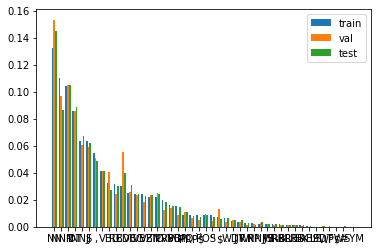

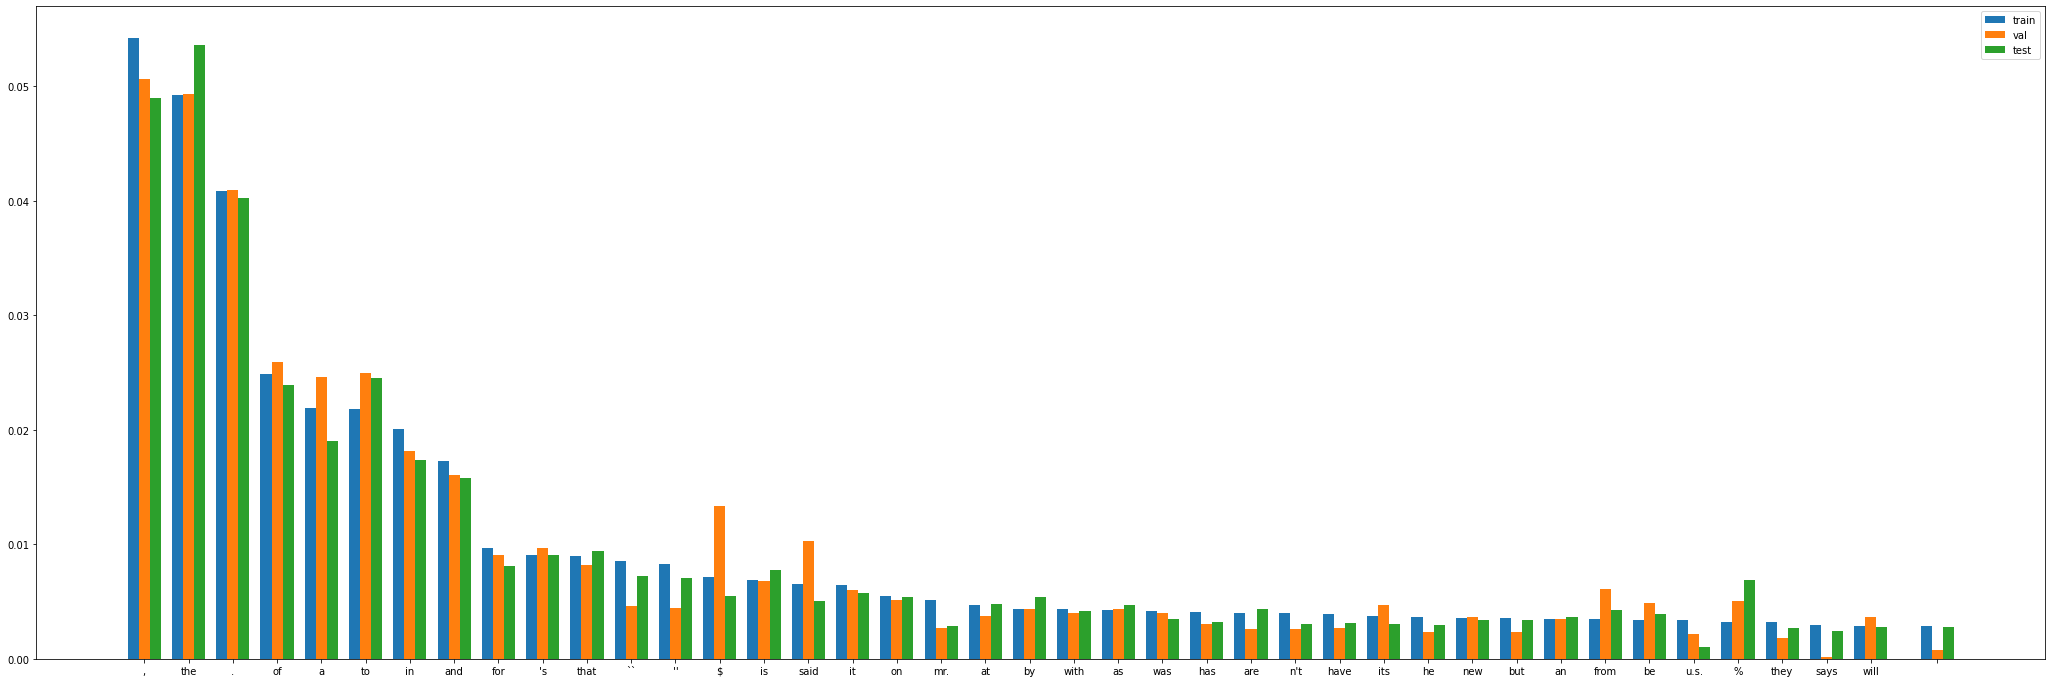

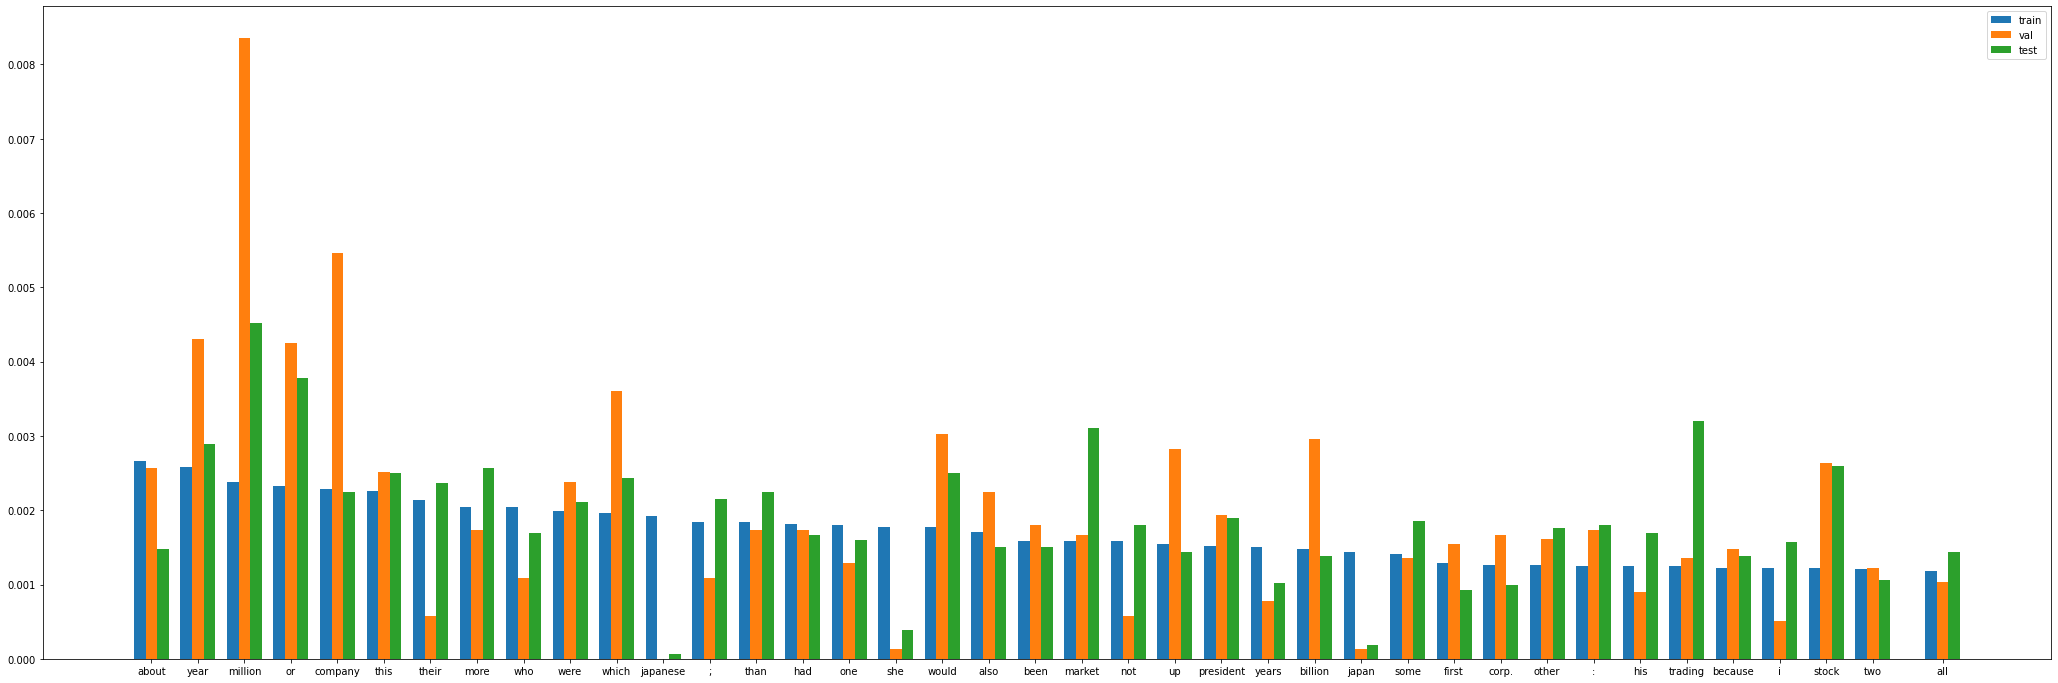

In [ ]:
from collections import Counter
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt

class Statistics():
  '''
  This class offers methods that give an insight to the distribution of words in train, validation and test sets.
  '''
  def __init__(self, train, test, val):
    '''
    It splits words and tags inside train, validation and test sets in different arrays, in order to work with them in a more convenient way.
    It also stores how many instances the three splits contain. Moreover it collects all the unique words that appear in all the splits. 
    It does the same with the unique labels but only of the train set. 
    '''
    self.train_words, self.train_labels, self.num_train_words= self._words_labels_arrays(train)
    self.val_words, self.val_labels, self.num_val_words = self._words_labels_arrays(val)
    self.test_words, self.test_labels, self.num_test_words = self._words_labels_arrays(test)
  
    self.count_train = len(train)
    self.count_val = len(val)
    self.count_test = len(test)
    self.labels = np.unique(self.train_labels)
    self.words = np.unique(np.concatenate([self.train_words, self.val_words, self.test_words])) 

  def _words_labels_arrays(_, data):
      '''
      It loops through all the instances of data (all the sentences in that set), and for each one, it goes through each element.
      This is of the form (word, tag), so it takes the first value of the tuple and it appends it to the list of words, it takes the second value and it appends it to the list
      of labels. 
      Params:
      data: it is a set of instances (sentences)
      Returns:
      words: it is a one dimentional array that contains all the words taken from the sentences inside data
      labels: it is a one dimentional array that contains all the labels taken from the sentences inside data
      '''
      words = []
      labels = []
      for sentence in data:
          for word in sentence:
              words.append(word[0])
              labels.append(word[1])
      return words, labels, len(words)
  
  def _occurrency_counts(_, keys, a):
    '''
    It computes a dictionary in which a key is a unique element and its value is the number of times this element appears in a
    '''
    dictionary = dict.fromkeys(keys, 0)
    unique, counts = np.unique(a, return_counts=True)
    for i in range(len(unique)):
      dictionary[unique[i]] = counts[i]
    return dictionary

  def distribution_of_splits(self):
    '''
    It returns the distribution of  number of sentences for each split.
    '''
    count_tot = self.count_train + self.count_val + self.count_test
    return self.count_train/count_tot,  self.count_val/count_tot, self.count_test/count_tot 
  
  def distribution_of_labels(self):
    '''
    It computes the occurrency counts of labels for train, validation and test sets.
    Then for each unique label, it ties it to an array containing all the occurrency counts previously computed.
    Check _fill_oc_dic documentation to have more details.
    '''
    oc_train, oc_val, oc_test =  self._occurrency_counts(self.labels, self.train_labels), self._occurrency_counts(self.labels, self.val_labels), self._occurrency_counts(self.labels, self.test_labels)
    return self._fill_oc_dic(oc_train, oc_val, oc_test)

  def distribution_of_words(self):
    '''
    It computes the occurrency counts of words for train, validation and test sets.
    Then for each unique word, it ties it to an array containing all the occurrency counts previously computed.
    Check _fill_oc_dic documentation to have more details.
    '''
    oc_train, oc_val, oc_test =  self._occurrency_counts(self.words, self.train_words), self._occurrency_counts(self.words, self.val_words), self._occurrency_counts(self.words, self.test_words)
    return self._fill_oc_dic(oc_train, oc_val, oc_test)

  def _fill_oc_dic(self, oc_train, oc_val, oc_test):
    '''
    for each unique key, it collects all the values bounded to that key in oc_train, oc_val and oc_test dictionaries.
    It then builds a new dictionary with the new keys and values and it sorts its element in a descending order.
    '''
    num_instances = [self.num_train_words, self.num_val_words, self.num_test_words]
    oc = defaultdict(list)
    for idx, d in enumerate([oc_train, oc_val, oc_test]): 
      for key, value in d.items():
        oc[key].append(value / num_instances[idx])

    return dict(sorted(oc.items(), key=lambda item: item[1][0], reverse = True))

  def label(_, i):
    '''
    Auxiliary function that, depending on the value of i, returns a string that is one of 'train', 'val' and 'test'
    '''
    label = ''
    if i == 0:
      label = 'train'
    elif i == 1:
      label = 'val'
    else: label = 'test'
    return label

  def plot_counts(self, dic, lower_bound = 0,  upper_bound = -1):
    '''
    It plots the distribution of words and labels in the train, validation and test sets.
    Params:
    dic: the dictionary that contains for each key the number of instances of that key in train, validation and test sets as its value.
    upper_bound (int) : it tells how many keys we have to consider when building the plot. By default it plots all the keys.  
    '''
    top=sorted(dic.items(), key=lambda x:x[1][0],reverse=True)[lower_bound:upper_bound] 
    figure = plt.figure()
    plt.rcParams['figure.figsize'] = (36.0, 12.0)
  

    x,y=zip(*top)
    n = len(x)
    r =np.linspace(1, 2*n, n, dtype = int)
    width = [-0.5, 0.0, 0.5 ]
    y= np.array(y)
    for i in range(3):
      plt.bar(r + width[i] ,y[:,i], label = self.label(i), width = 0.5)
  
    plt.xticks(r, x)
    plt.legend()
    plt.show()

stat = Statistics(train_list, val_list, test_list)
splits_distribution = stat.distribution_of_splits()
dic_labels = stat.distribution_of_labels()
dic_words = stat.distribution_of_words()
stat.plot_counts(dic_labels)
stat.plot_counts(dic_words, upper_bound = 41)
stat.plot_counts(dic_words, lower_bound = 41, upper_bound = 80)


In the first plot there is the distribution of tags in train, validation and test splits. We can observe that the most prevalent tags, in all the splits, are **NN (noun)**, **NNP (proper noun)**,  **IN (preposition or subordinating conjunction)** and **DT (determinant)**, whereas the most rare are, predictably, **SYM (symbols)**, **FW (foreign words)**, **LS (list item marker)**, **RBS (superlatives)**, **PDT (predeterminer)**, **EX (existential there)**. Infact these tags are used in very specific contests.

Overall for each tag, we have more or less the same distribution among train, validation and test splits, except for a few outliers like **CD** (cardinal number) and **$**, in which the value of the validation split is way greater than the others coming from train and test splits.

For what concerns the distribution of words:
* first plot shows the distribution of the **40 most frequent words**
* second plot shows the distribution of words in range **[40th most frequent word - 80th most frequent word
]**

Also in this case the most frequent words are more or less equally distributed in the 3 splits. The situation changes when we look at more rare words (second plot). Here the distribution values of the splits can be very different.



### GloVe embeddings vectorization and one-hot enconding
The next step consists in downloading a pre-trained embedding model, namely **GloVe**. 

GloVe is a method for creating **word embeddings**, which are numerical representations of words that capture their meanings and the relationships between them. These embeddings are created by training a model on a **large dataset of words and their co-occurrences**, and using the learned relationships to generate vectors for each word. GloVe is widely used in natural language processing tasks and has been shown to be effective in a variety of applications. It is often used as a baseline model for comparison with other word embedding techniques, and it is often used as an initial set of word vectors for further training on specific tasks. 

In our case we are interested in using it as  **initial set of word vectors**. It is possible to specify different values for the embedding dimension (by default we set it to **100**).

From the choosen embedding model, a **starting vocabulary** is built. Then this vocabulary is enriched with the embeddings computed for the **OOV words**. These ones are randomly generated by sampling from a **normal distribution** in range [-1, 1].

In this section also each POS tag in each split is converted using the one-hot representation (using a LabelBinarizer object as encoder)

In [ ]:
class Embedder():
    '''
    It handles the creation of the data frame. This one has 3 dimensions: 1-sentences, 2-token, 3-features.
    The features are glove embeddings. It also computes one hot encodings from tag strings.
    '''
    def __init__(
        self,
        train, 
        val, 
        test,
        max_sentence_size,
        embedding_dimension = 100,
    ):
        '''
        The constructor creates the embedding model from the embedding dimension and the encoder object responsible for the one hot encoding. 
        It also stores on its local variables the max sentence size, the embedding dimension, train, validation and test sets.
        '''
        self.embedding_model = self._load_embedding_model(embedding_dimension)
        self.max_sentence_size  = max_sentence_size
        self.embedding_dimension = embedding_dimension
        self.train = train
        self.val = val
        self.test = test
        self.encoder = LabelBinarizer()

    def _load_embedding_model(self, embedding_dimension = 100):
        '''
        This method downloads locally the glove embedding model. The number of features for each word in this vocabulary is equal to 
        the value of the argument embedding_dimension. It then loads the model and it returns it. 
        '''
        loading_dir_path = os.path.join(os.getcwd(), "embedding_model")
        loading_model_path = os.path.join(loading_dir_path, "model.bin")
        download_path = "glove-wiki-gigaword-{}".format(embedding_dimension)
        emb_model = gloader.load(download_path)
        return emb_model 
    
    def handling_oov_terms(self):
        '''
        It generates 4 different vocabularies. 
        It starts with the glove vocabulary v1. It computes random embeddings for terms out of vocabulary of the training split 
        and it adds these embeddings to the vocabulary, generating v2.
        The same procedure is applied for the generation of vocabularies v3 and v4, with the difference that OOV words are of validation and test splits.
        '''

        #starting vocabulary V1 (GloVe vocabulary)
        v1 = self.embedding_model
        #compute embeddings for terms out of vocabulary V1 (OOV1) of the training split
        oov_terms_train = self._check_OOV_terms(v1, self.train, "1")
        #add embeddings to the vocabulary, so to obtain vocabulary V2=V1+OOV1
        v2 = self._add_OOV_terms(v1, oov_terms_train)
        #compute embeddings for terms OOV2 of the validation split
        oov_terms_val = self._check_OOV_terms(v2, self.val, "2")
        #add embeddings to the vocabulary, so to obtain vocabulary V3=V1+OOV1+OOV2
        v3 = self._add_OOV_terms(v2, oov_terms_val)
        #compute embeddings for terms OOV3 of the test split
        oov_terms_test = self._check_OOV_terms(v3, self.test, "3")
        #add embeddings to the vocabulary, so to obtain vocabulary V4=V1+OOV1+OOV2+OOV3
        v4 = self._add_OOV_terms(v3, oov_terms_test)
        return v1, v2, v3, v4

    def _check_OOV_terms(self, vocabulary, dataset, v_num):
        '''
        It takes all the words in dataset that are not in the keys of vocabulary and it returns them. These are the OOV terms of vocabulary.
        Params:
        vocabulary: a vocabulary with embeddings as values 
        dataset: it is the dataset used to find the OOV words
        v_num (str) : it is the id of the vocabulary 
        '''
        embedding_vocabulary = set(vocabulary.vocab.keys())
        word_listing = set()
        for sentence in dataset:
          for couple in sentence:
            word, _ = couple
            word_listing.add(word)
        oov = word_listing.difference(embedding_vocabulary)

        oov_percentage = float(len(list(oov))) * 100 / len(word_listing)
        print(f"Total OOV terms in V{v_num}: {len(list(oov))} ({oov_percentage:.2f}%)")
        return list(oov)

    def _add_OOV_terms(self, vocabulary, oov):
        '''
        Params:
        vocabulary: the vocabulary we want to extend with ovv terms
        oov: a list of words that are not in vocabulary

        Returns:
        a new vocabulary built upon the previous one, with the difference that it has an entry for each of the oov terms.
        Values of the features of  each embedding  are randomly sampled from a normal distribution in the range -1, 1.
        '''
        voc = copy.deepcopy(vocabulary)
        for word in oov:
          voc[word] = np.random.uniform(-1, 1, size=self.embedding_dimension)
        print(f"Generated embeddings for {len(oov)} OOV words.")
        return voc

    def build_embeddings_df(self, vocabulary, df_type):
        '''
        It builds the final dataset, that has 3 dimensions: 1-sentences, 2-words, 3-features (glove embeddings).
        Params:
        vocabulary: set of embeddings that we want to add in place of words in the returned dataset.
        df_type (str): it specifies what is the split we want to transform in the 3-dimensional dataset. 

        Returns:
        A 3-dimensional dataset in which for each sentence, for each word in the sentence, there is an embedding associated to that word. If the sentence is too short, 
        padding embeddings are added (embeddings with all 0s as features) until the number of words is equal to the one of the longest sentence.
        It also returns all the tags in a list of lists.
        '''
        if df_type == 'train':
          df = self.train
        elif df_type == 'validation':
          df = self.val
        else: df = self.test

        df_rows = []
        ys = []
        for sentence in df:
          embeddings_row = np.array([vocabulary[word] for word, _ in sentence])
          df_rows.append(
              np.vstack(
                  (embeddings_row,np.zeros((self.max_sentence_size - len(sentence), self.embedding_dimension)),
                         )
              )
          )
          y = [target for _, target in sentence]
          ys.append(y)

        return np.array(df_rows), np.array(ys)

    def one_hot_encode(self, y, is_fit = False):
        '''
        Params:
        y: list of tags (that are strings), that we want to transform in one hot encoding
        is_fit (bool) : if True, y is used to fit the one hot encoder. Otherwise only the transform is applied to y.

        Returns: 
        A 3-dimensional array in which for each sentence, for each tag in the sentence, there is a one hot encoding associated to that tag. If the sentence is too short, 
        padding encodings are added (one hot encodings with all 0s,  as we did in build_embeddings_df for the embeddings) until the number of tags is equal to the one of the longest sentence.
        '''
        y_onehot = []

        if is_fit:
          self.encoder.fit([word for sentence in y for word in sentence])

        for sentence in y:
          y_onehot_row = self.encoder.transform(sentence)
          padding_row = np.zeros((self.max_sentence_size - len(y_onehot_row), len(self.encoder.classes_)))
          y_onehot.append(
              np.vstack(
                  ( 
                    y_onehot_row,
                    padding_row,  
                  )
              )
          )
        return np.array(y_onehot)

In [ ]:
embedded_data = Embedder(train_list, val_list, test_list, max_size)
v1, v2, v3, v4 = embedded_data.handling_oov_terms()

enc_X_train, y_train = embedded_data.build_embeddings_df(v2, 'train')
enc_X_val, y_val = embedded_data.build_embeddings_df(v3, 'validation')
enc_X_test, y_test = embedded_data.build_embeddings_df(v4, 'test')

enc_y_train = embedded_data.one_hot_encode(y_train, is_fit = True)
enc_y_val = embedded_data.one_hot_encode(y_val)
enc_y_test = embedded_data.one_hot_encode(y_test)

Total OOV terms in V1: 157 (2.22%)
Generated embeddings for 157 OOV words.
Total OOV terms in V2: 81 (1.55%)
Generated embeddings for 81 OOV words.
Total OOV terms in V3: 68 (2.07%)
Generated embeddings for 68 OOV words.


<ipython-input-7-03ac07d9d441>:128: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return np.array(df_rows), np.array(ys)


In [ ]:
embedding_dimension = 100
num_classes = 45
input_shape = (max_size, embedding_dimension)

## Models


After having preprocessed the original dataset, splitting it into a train set (1-100 documents), a validation set (101-150 documents), and a test set (151-199 documents), and after having split the documents into sentences and created the I/O structure as requested, we proceed by defining a baseline model: a two-layer architecture that contains a bidirectional LSTM layer and a dense/fully-connected layer on top. We then experiment using three other models and compare them based on the validation accuracy. According to the latter, we choose the best two models. Eventually we evaluate them on the test set.

Each model is defined using the Keras Sequential API, which allows us to define a model by stacking layers sequentially.

Each model is compiled using as loss the categorical crossentropy (which predicts a class label from a set of mutually exclusive classes, by calculating the negative log likelihood of the true classes, given the predicted probabilities for each classes), as optimizer Adam, and as metric the accuracy.

**Experiments**.
We ran many experiments (only on training and validation set) involving the four models, using a combination of grid search and manual search. At first, we used grid search, but since the training for each model, for each hyperparameter, took too much time, we decided to take the values that were giving the best results and switch to manual search.

### Baseline model.
The baseline architecture consists of a single **Masking** layer, used to ignore the padding in the input data, which can improve the performance of the model. Then a **Bi-LSTM** layer, which processes the input data both in a forward and backward fashion, is stacked up.

A Long Short-Term Memory (LSTM) layer is a type of recurrent neural network (RNN) designed to capture long-term dependencies in sequential data (like in a text document). It does so by using three gates: an input gate, an output gate, and a forget gate, which manage what information has to be remembered or forgotten.

The return_sequences is set to True, this means that the layer will output a sequence of values (one output for each input time step). On top of that we have a **TimeDistributed** layer which applies a **fully-connected** layer to each time step of the input data. The dense layer has 45 output units and it produced a probability distribution over the output classes thanks to the softmax activation function.

In [ ]:
def baseline_model(input_shape):
    model = Sequential()
    model.add(Masking(mask_value=0, input_shape=input_shape))

    model.add(Bidirectional(LSTM(64, return_sequences = True, dropout = 0.1)))
    model.add(TimeDistributed(Dense(num_classes, activation = 'softmax')))

    return model

In [ ]:
baseline_early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta = 0.008,
    patience = 5,
    restore_best_weights=True,
    verbose=True
)

In [ ]:
baseline_model = baseline_model(input_shape)

In [ ]:
baseline_model.compile(loss='categorical_crossentropy', optimizer = Adam(), metrics=["accuracy"])

In [ ]:
# Build the model with the optimal hyperparameters and train it on the data for 50 epochs
baseline_model.summary()
baseline_history = baseline_model.fit(enc_X_train, enc_y_train, batch_size=32, epochs=50, validation_data=(enc_X_val, enc_y_val), callbacks=[baseline_early_stopping])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 masking (Masking)           (None, 249, 100)          0         
                                                                 
 bidirectional (Bidirectiona  (None, 249, 128)         84480     
 l)                                                              
                                                                 
 time_distributed (TimeDistr  (None, 249, 45)          5805      
 ibuted)                                                         
                                                                 
Total params: 90,285
Trainable params: 90,285
Non-trainable params: 0
_________________________________________________________________
Epoch 1/50
62/62 [==============================] - 14s 67ms/step - loss: 0.2627 - accuracy: 0.3261 - val_loss: 0.1938 - val_accuracy: 0.5151
Epoch 2/50
62/62 [========================

### Two-Dense-Model: Baseline model with two fully connected layers.
The difference between the second model and the Baseline one is the presence of another TimeDistributed layer which applies a 249-units fully-connected layer to each time step.

The idea behind this choice is that the first Dense layer can be useful to learn complex patterns in the word embeddings as well as in the sentence as a whole, while the second one will be used to make the final prediction. The dropout layer can help to reduce overfitting.

In [ ]:
def two_dense_model(input_shape):
    model = Sequential()
    model.add(Masking(mask_value=0, input_shape=input_shape))

    model.add(Bidirectional(LSTM(64, return_sequences = True, dropout=0.1)))
    model.add(TimeDistributed(Dense(units=249, activation = 'relu')))
    model.add(Dropout(rate=0.1))
    model.add(TimeDistributed(Dense(num_classes, activation = 'softmax')))

    return model

In [ ]:
two_dense_early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta = 0.008,
    patience = 5,
    restore_best_weights=True,
    verbose=True
)

In [ ]:
two_dense_model = two_dense_model(input_shape)

In [ ]:
two_dense_model.compile(loss='categorical_crossentropy', optimizer = Adam(), metrics=["accuracy"])

In [ ]:
# Build the model with the optimal hyperparameters and train it on the data for 50 epochs
two_dense_model.summary()
two_dense_history = two_dense_model.fit(enc_X_train, enc_y_train, batch_size=32, epochs=50, validation_data=(enc_X_val, enc_y_val), callbacks=[two_dense_early_stopping])

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 masking_1 (Masking)         (None, 249, 100)          0         
                                                                 
 bidirectional_1 (Bidirectio  (None, 249, 128)         84480     
 nal)                                                            
                                                                 
 time_distributed_1 (TimeDis  (None, 249, 249)         32121     
 tributed)                                                       
                                                                 
 dropout (Dropout)           (None, 249, 249)          0         
                                                                 
 time_distributed_2 (TimeDis  (None, 249, 45)          11250     
 tributed)                                                       
                                                      

### Two-LSTM-Model: Baseline model with two Bi-LSTM layers.
The difference between the third model and the Baseline one is the presence of another Bi-LSTM layer.

This type of architecture could be useful for tasks that require modeling long-term dependencies in the data.

In [ ]:
def two_lstm_model(input_shape):
    model = Sequential()
    model.add(Masking(mask_value=0, input_shape=input_shape))

    model.add(Bidirectional(LSTM(64, return_sequences = True, dropout=0.1)))
    model.add(Bidirectional(LSTM(64, return_sequences = True, dropout=0.1)))

    model.add(TimeDistributed(Dense(num_classes, activation = 'softmax')))
    
    return model

In [ ]:
two_lstm_early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta = 0.008,
    patience = 5,
    restore_best_weights=True,
    verbose=True
)

In [ ]:
two_lstm_model = two_lstm_model(input_shape)

In [ ]:
two_lstm_model.compile(loss='categorical_crossentropy', optimizer = Adam(), metrics=["accuracy"])

In [ ]:
# Build the model with the optimal hyperparameters and train it on the data for 50 epochs
two_lstm_model.summary()
two_lstm_history = two_lstm_model.fit(enc_X_train, enc_y_train, batch_size=32, epochs=50, validation_data=(enc_X_val, enc_y_val), callbacks=[two_lstm_early_stopping])

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 masking_2 (Masking)         (None, 249, 100)          0         
                                                                 
 bidirectional_2 (Bidirectio  (None, 249, 128)         84480     
 nal)                                                            
                                                                 
 bidirectional_3 (Bidirectio  (None, 249, 128)         98816     
 nal)                                                            
                                                                 
 time_distributed_3 (TimeDis  (None, 249, 45)          5805      
 tributed)                                                       
                                                                 
Total params: 189,101
Trainable params: 189,101
Non-trainable params: 0
________________________________________________

### GRU Model
The Masking layer is already described above as well as the TimeDistributed-Dense layer.

Here the LSTM layer is replaced with a GRU (Gated Recurrent Unit), which is also a type of RNN used to manage what information has to be remembered/forgotten. The difference between the two is that the GRU layer has only two gates, an update gate and a reset gate. The output of the layer at each time step is a weighted combination of the input data and the previous stare of the layer itself.

In [ ]:
def GRU_model(input_shape):
    model = Sequential()
    model.add(Masking(mask_value=0, input_shape=input_shape))

    model.add(Bidirectional(GRU(64, return_sequences = True, dropout=0.1)))
    model.add(TimeDistributed(Dense(num_classes, activation = 'softmax')))

    return model

In [ ]:
gru_early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta = 0.008,
    patience = 5,
    restore_best_weights=True,
    verbose=True
)

In [ ]:
gru_model = GRU_model(input_shape)

In [ ]:
gru_model.compile(loss='categorical_crossentropy', optimizer = Adam(), metrics=["accuracy"])

In [ ]:
# Build the model with the optimal hyperparameters and train it on the data for 50 epochs
gru_model.summary()
gru_history = gru_model.fit(enc_X_train, enc_y_train, batch_size=32, epochs=50, validation_data=(enc_X_val, enc_y_val), callbacks=[gru_early_stopping])

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 masking_3 (Masking)         (None, 249, 100)          0         
                                                                 
 bidirectional_4 (Bidirectio  (None, 249, 128)         63744     
 nal)                                                            
                                                                 
 time_distributed_4 (TimeDis  (None, 249, 45)          5805      
 tributed)                                                       
                                                                 
Total params: 69,549
Trainable params: 69,549
Non-trainable params: 0
_________________________________________________________________
Epoch 1/50
62/62 [==============================] - 11s 63ms/step - loss: 0.2470 - accuracy: 0.3622 - val_loss: 0.1605 - val_accuracy: 0.5687
Epoch 2/50
62/62 [======================

In [ ]:
#scegliere i due modelli migliori

### Plot History
For each model we plot the training and validation accuracy/loss during training, in order to ensure no model is overfitting.

In [ ]:
import matplotlib.pyplot as plt

def plot_history(model_history, keys, early_stopping):
    m, val_m = keys
    plt.plot(model_history.history[m][:early_stopping.best_epoch])
    plt.plot(model_history.history[val_m][:early_stopping.best_epoch])
    # plt.ylabel(m)
    # plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()


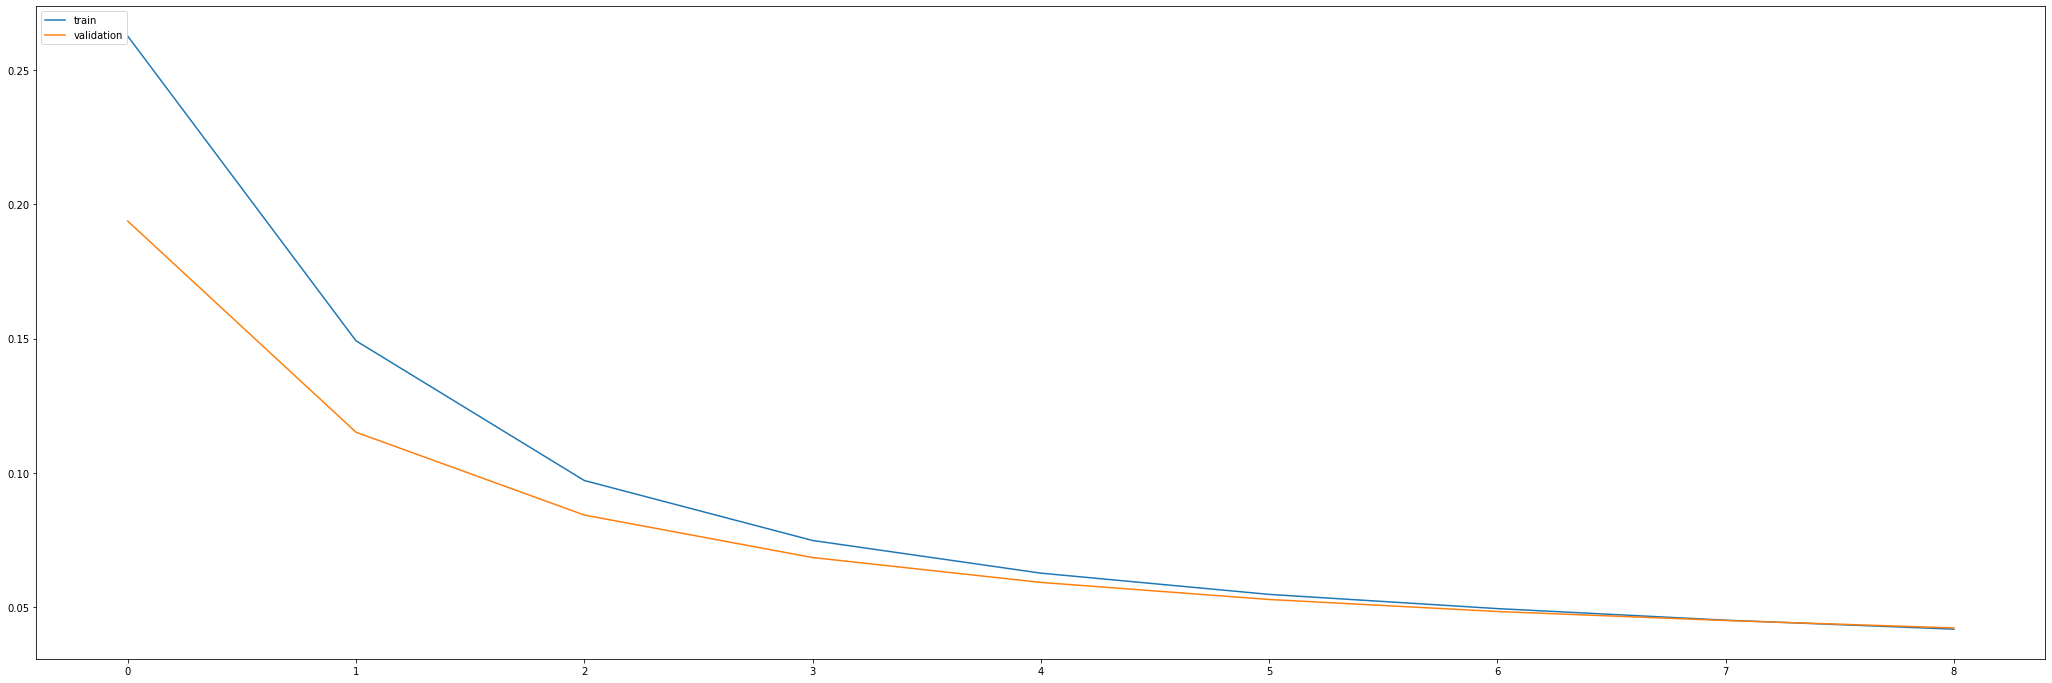

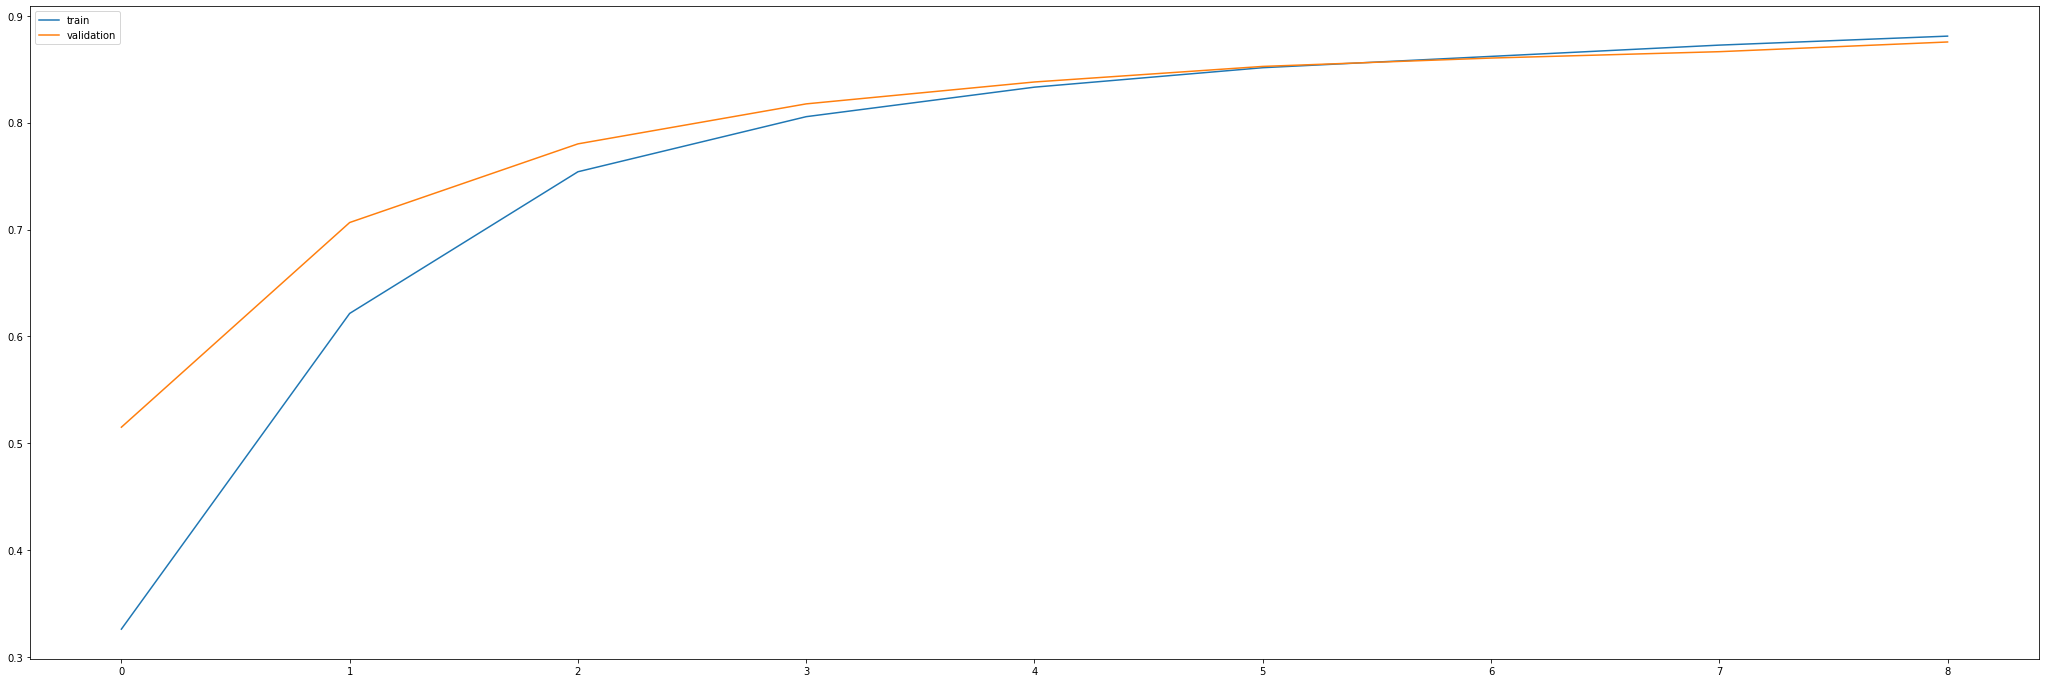

In [ ]:
#baseline
plot_history(baseline_history, ['loss','val_loss'], baseline_early_stopping)
plot_history(baseline_history, ['accuracy','val_accuracy'], baseline_early_stopping)

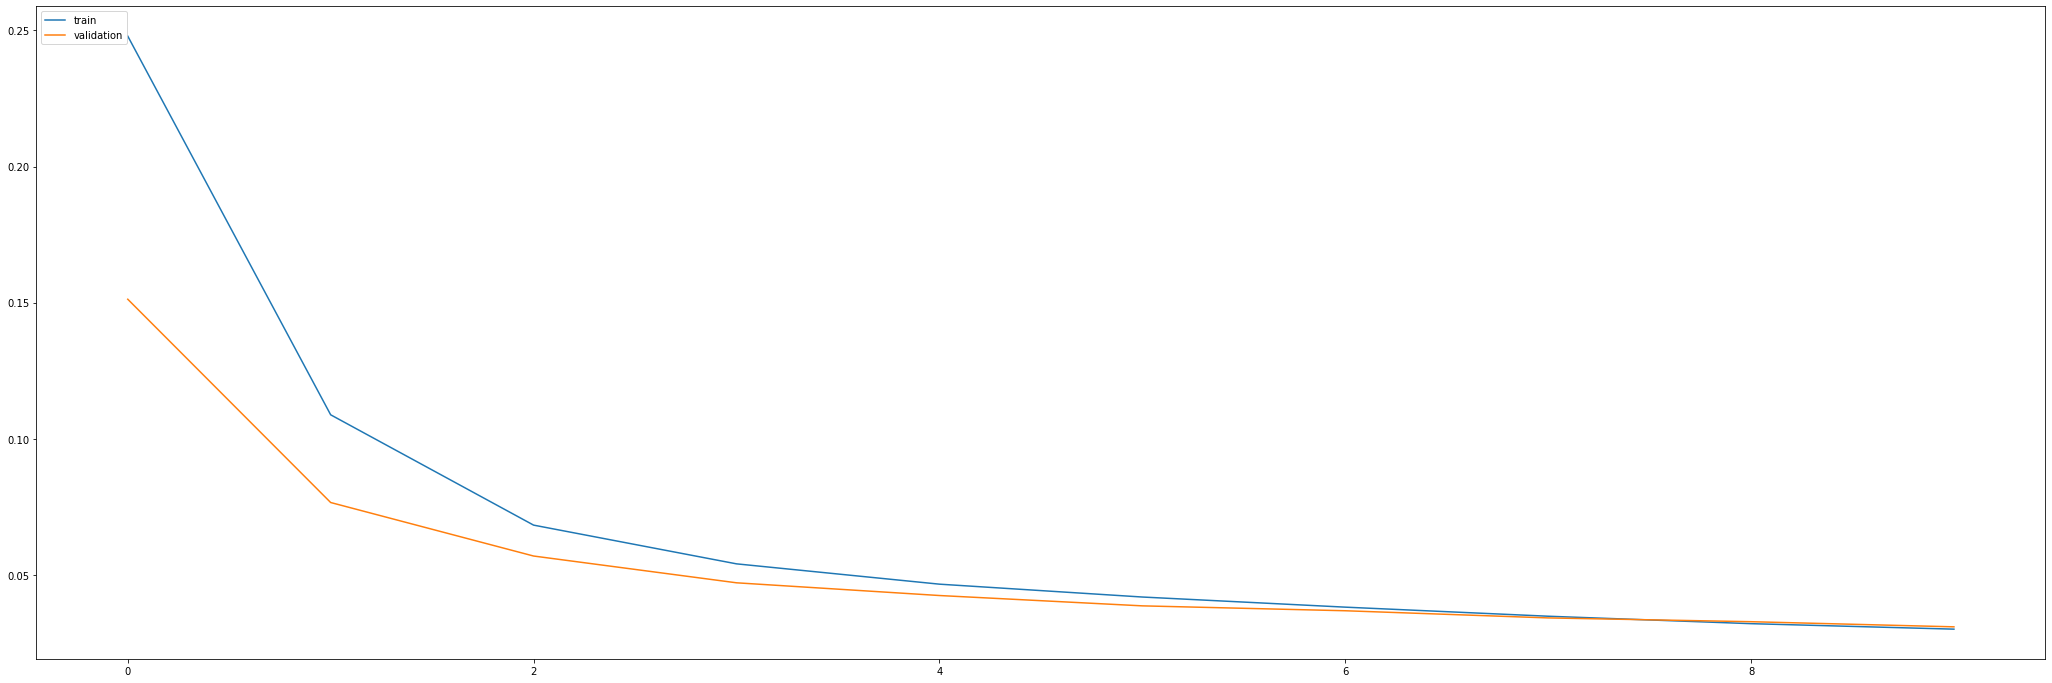

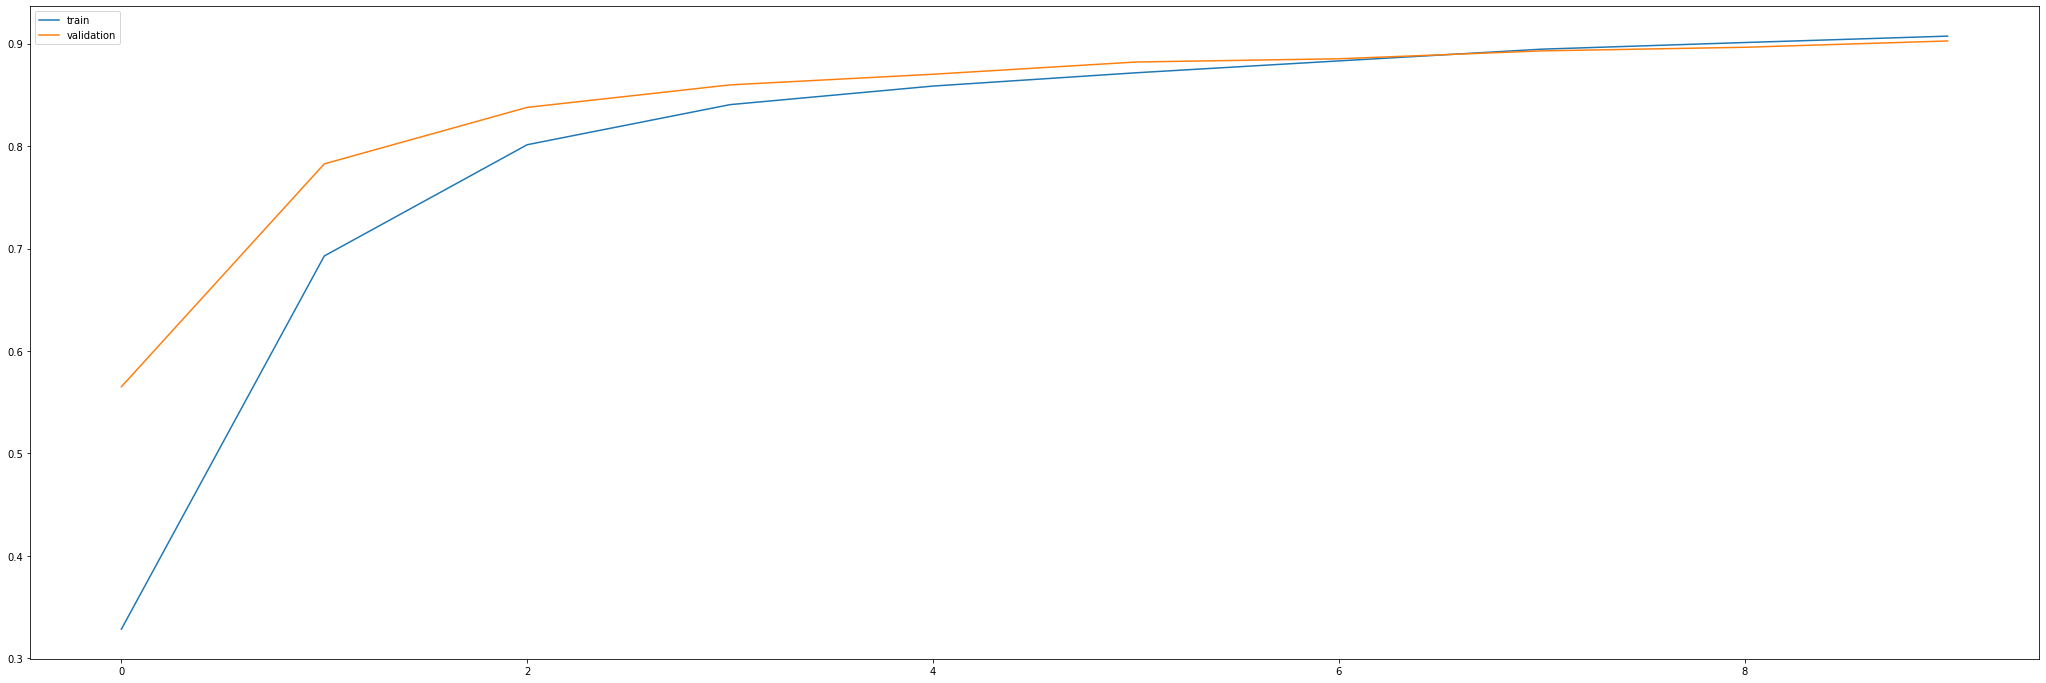

In [ ]:
plot_history(two_dense_history, ['loss','val_loss'], two_dense_early_stopping)
plot_history(two_dense_history, ['accuracy','val_accuracy'], two_dense_early_stopping)

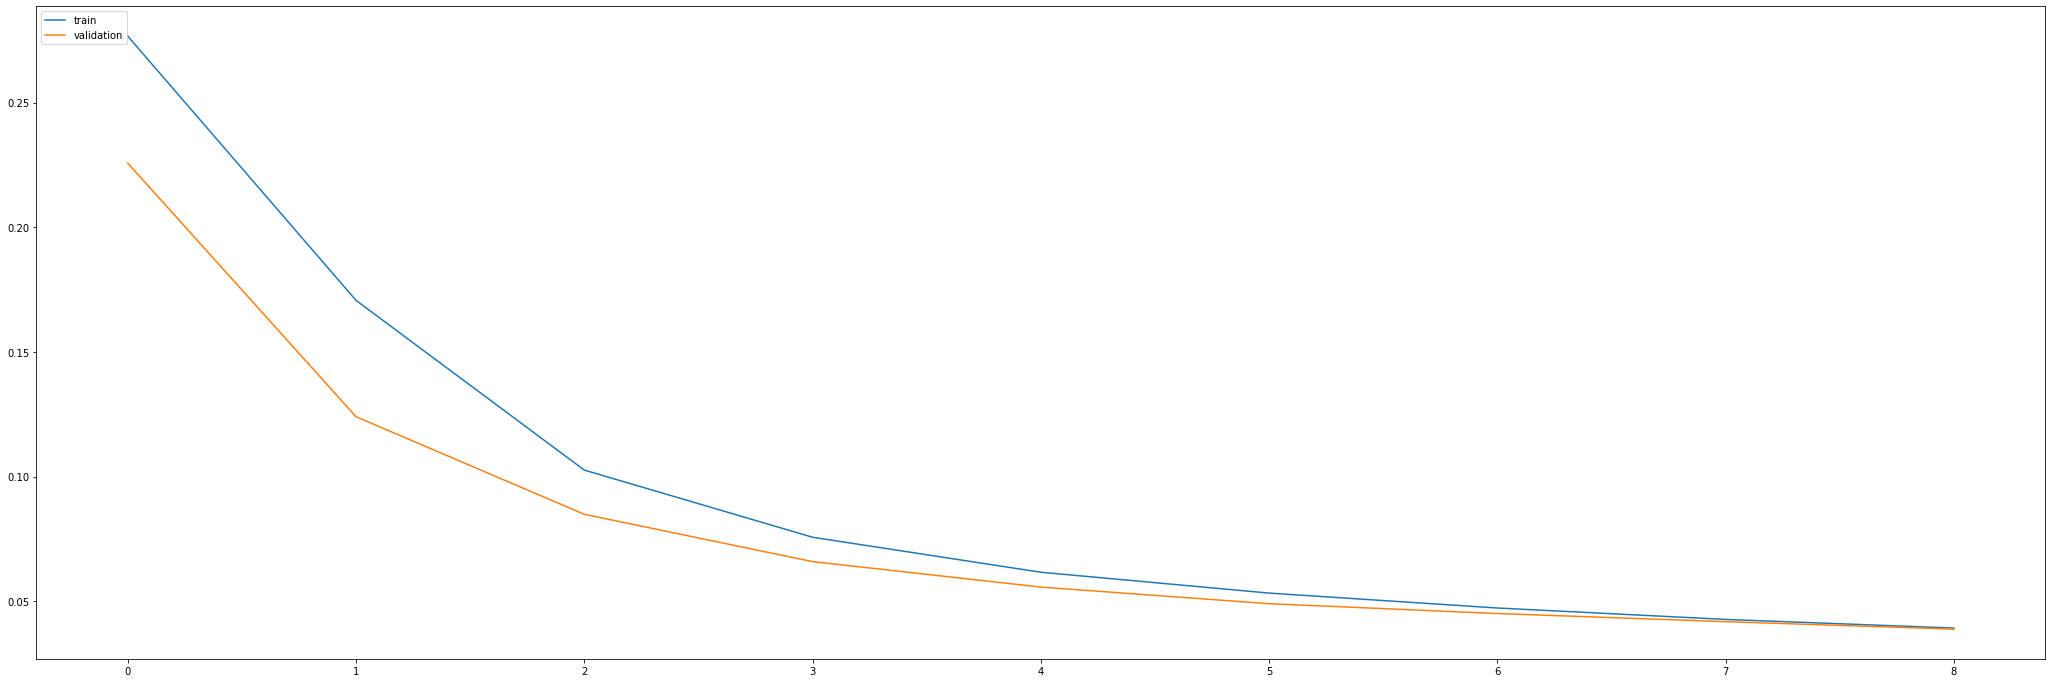

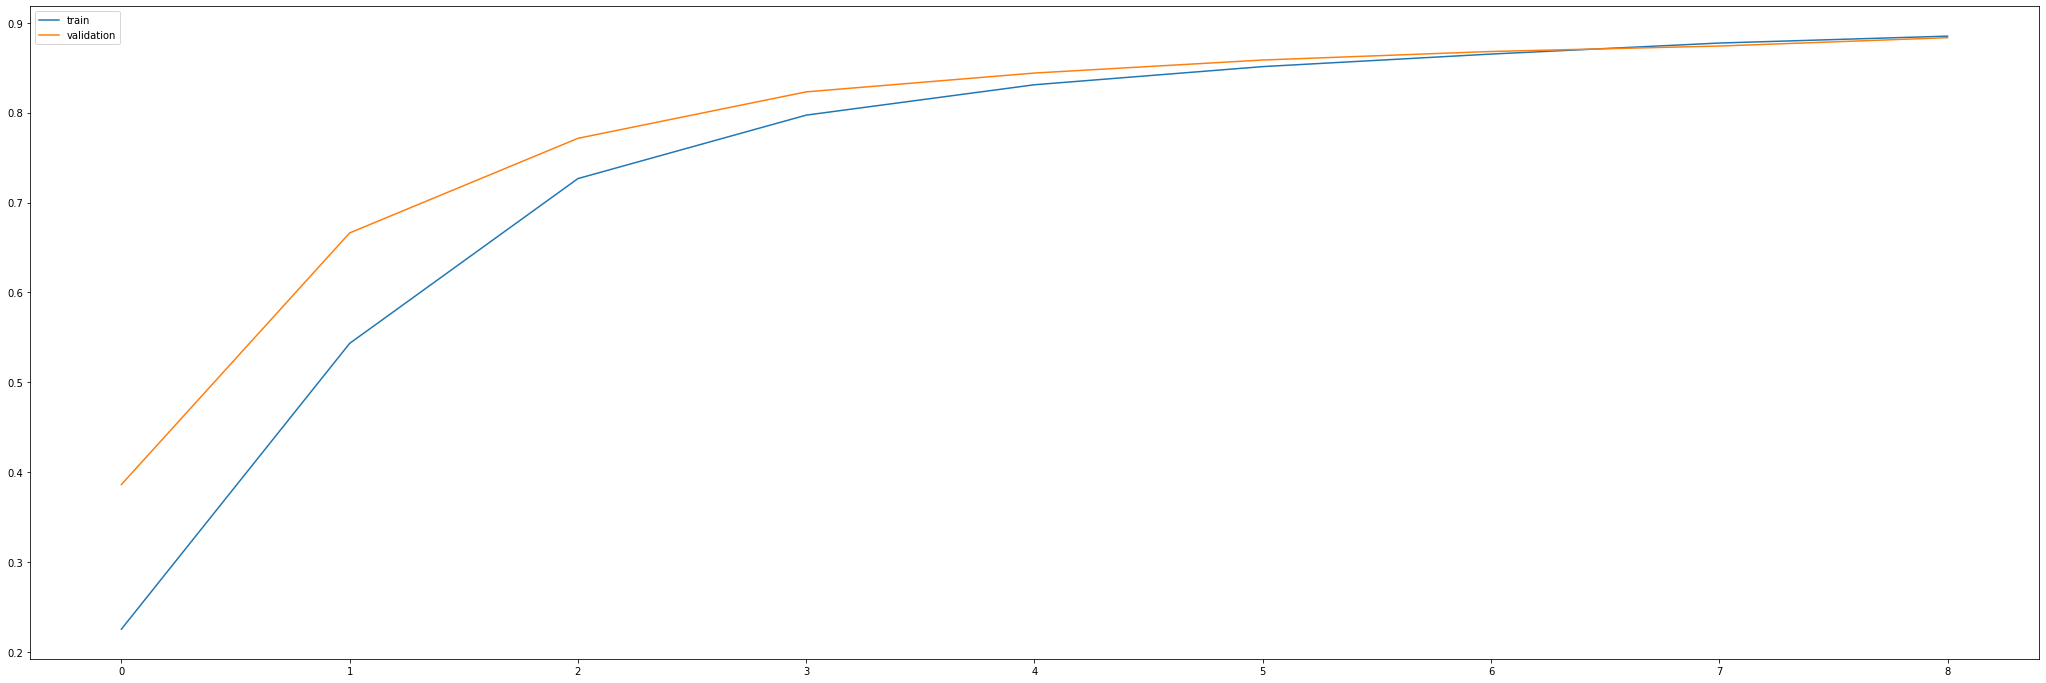

In [ ]:
plot_history(two_lstm_history, ['loss','val_loss'], two_lstm_early_stopping)
plot_history(two_lstm_history, ['accuracy','val_accuracy'], two_lstm_early_stopping)

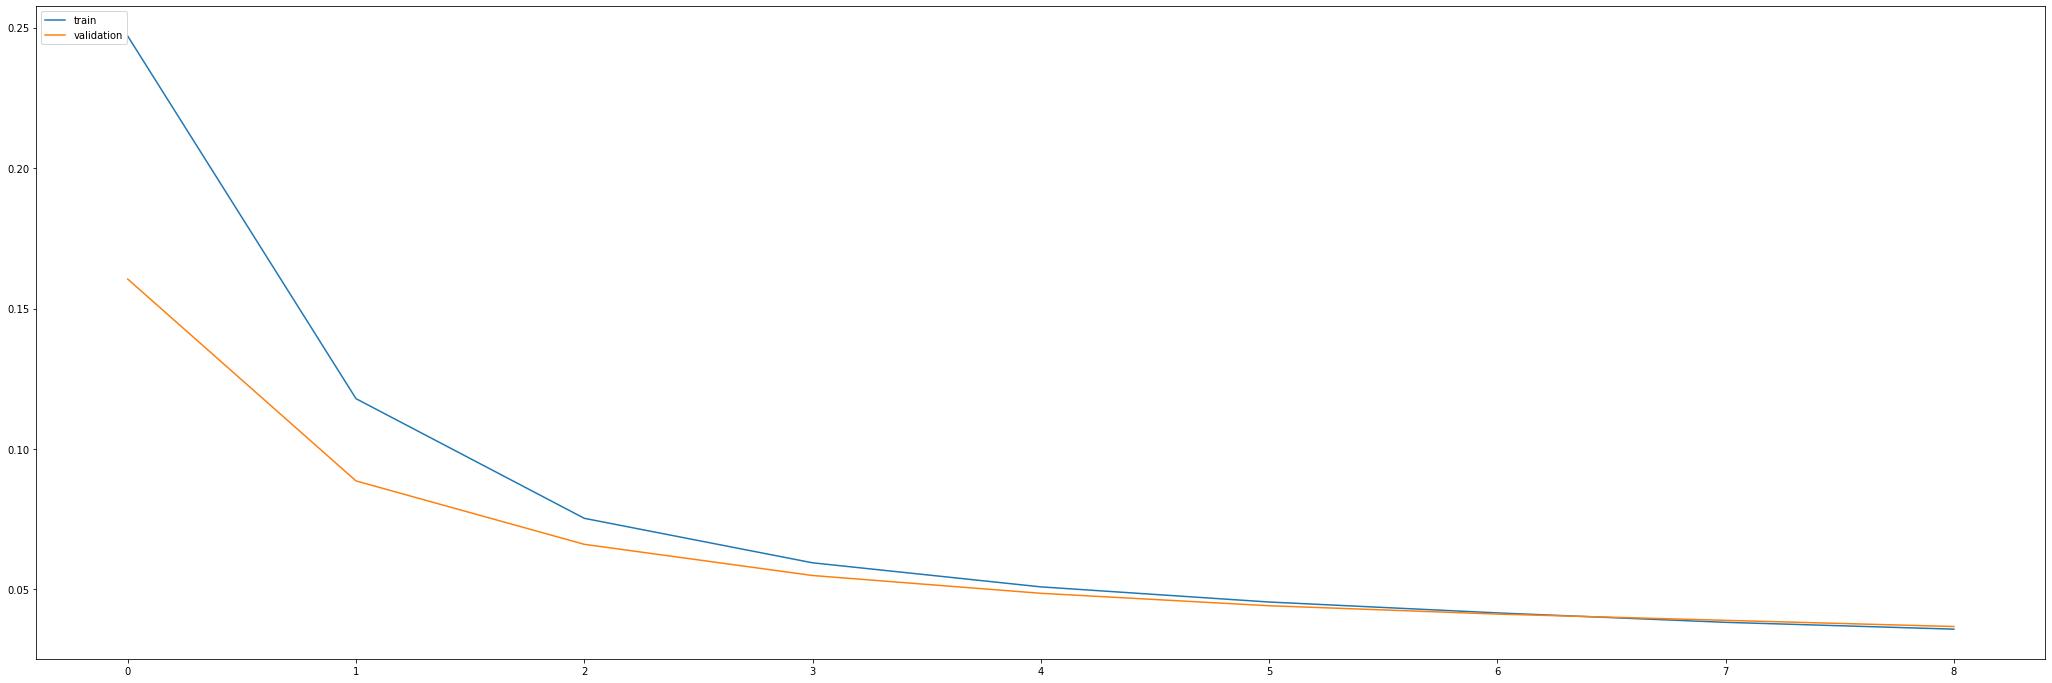

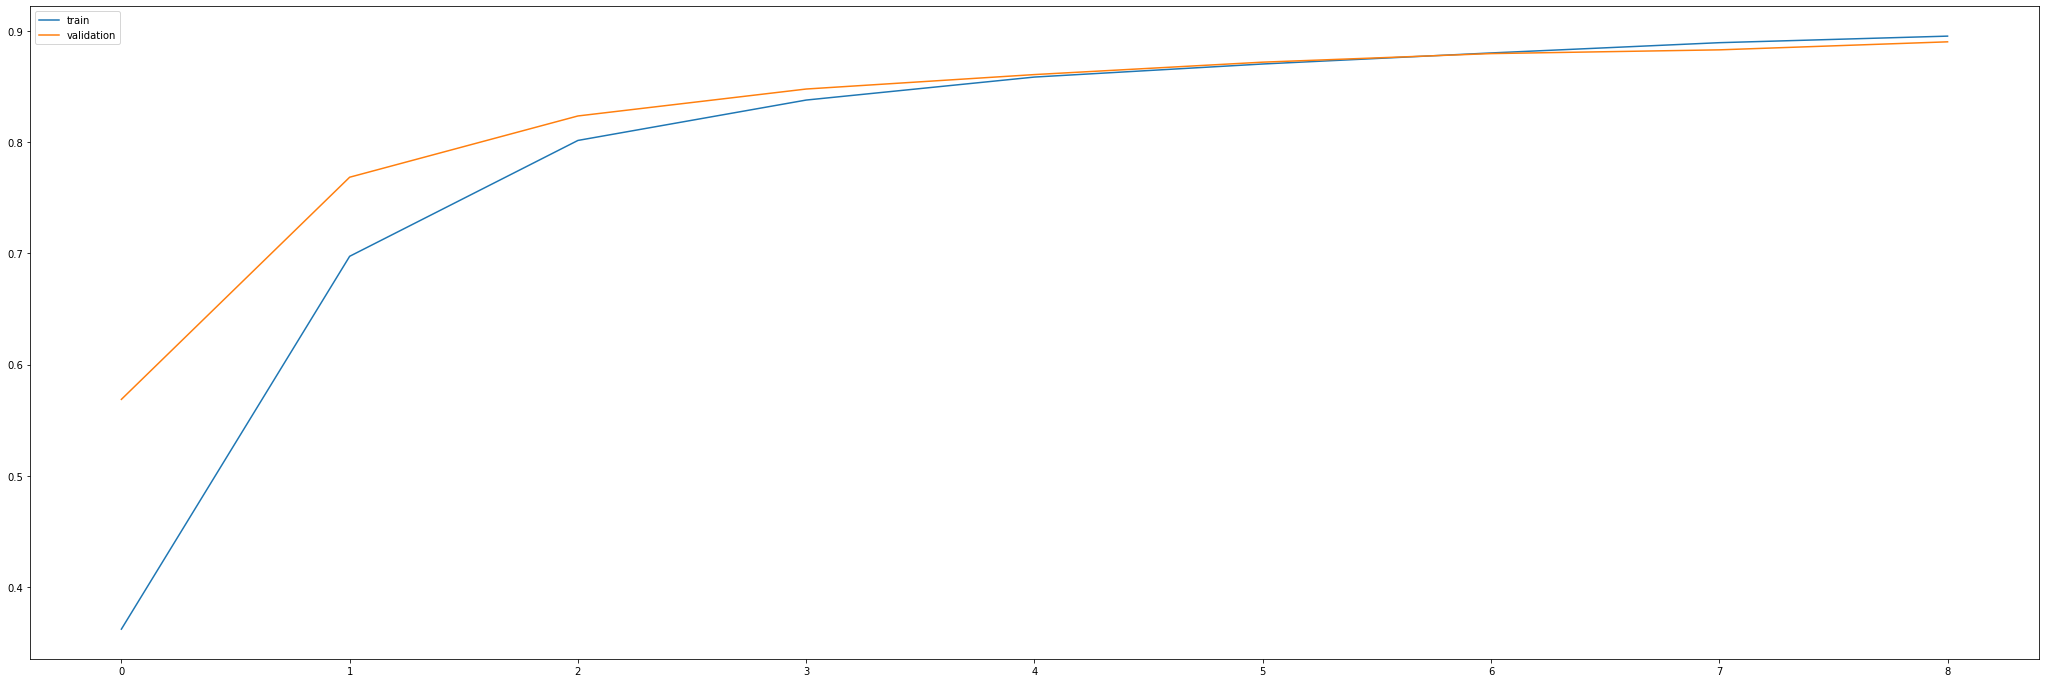

In [ ]:
plot_history(gru_history, ['loss','val_loss'], gru_early_stopping)
plot_history(gru_history, ['accuracy','val_accuracy'], gru_early_stopping)

### Choosing the best two models
According to the validation accuracy, the best two models are:

* Two-Dense-Model -> val accuracy: *0.9159*
* GRU model -> val accuracy: *0.9065*


INSERIRE CODICE CHE MOSTRA CHE SONO EFFETTIVAMENTE I MIGLIORI TIPO UN PRINT 

## Evaluation of models
Finally the test set is evaluated only on the two best models.

The F1-score is only used to evaluate labels that are not punctuations or symbols.

The Two-Dense model performs slightly better than the GRU model.

**Error analysis**.
The error analysis is performed with the use of a confusion matrix and a classification report. Thanks to these tools we are able to identify on which classes the models are performing well, and those areas where they need improvement.

In [ ]:
from sklearn.metrics import f1_score

def prob_to_onehot(predictions):
  for sentence in predictions:
    for tag in sentence:
      max = np.argmax(np.array(tag))
      tag[max] = 1
      tag[tag!=1] = 0
  return predictions

def remove_padding(y, test_list):
  y_cut = []
  for i, sentence in enumerate(test_list):
      y_cut.append(y[i][0:len(sentence)])
  return y_cut

def inverse_transform(y, one_hot_encoder):
  y_cut = []
  for i in range(len(test_list)):
      y_cut.append(one_hot_encoder.inverse_transform(y[i]))
  return y_cut

def remove_symbols(one_hot_encoder):
  symbs = ['#', '$', "''", ',', '-LRB-', '-RRB-', '.', ':', 'SYM', '``']
  labels = list(one_hot_encoder.classes_)
  for sym in symbs:
    labels.remove(sym)
  return labels


In [ ]:
one_hot_encoder = embedded_data.encoder
true_labels = remove_symbols(one_hot_encoder)

In [ ]:
y_true = enc_y_test
y_true = inverse_transform(y_true, one_hot_encoder)
y_true = remove_padding(y_true, test_list)

td_y_pred = two_dense_model.predict(enc_X_test)
td_y_pred = prob_to_onehot(td_y_pred)
td_y_pred = inverse_transform(td_y_pred, one_hot_encoder)
td_y_pred = remove_padding(td_y_pred, test_list)

gru_y_pred = gru_model.predict(enc_X_test)
gru_y_pred = prob_to_onehot(gru_y_pred)
gru_y_pred = inverse_transform(gru_y_pred, one_hot_encoder)
gru_y_pred = remove_padding(gru_y_pred, test_list)

21/21 [==============================] - 2s 7ms/step


In [ ]:
from itertools import chain

flattened_y_true = list(chain.from_iterable(y_true))
flattened_td_y_pred = list(chain.from_iterable(td_y_pred))
flattened_gru_y_pred = list(chain.from_iterable(gru_y_pred))

In [ ]:
two_dense_score = f1_score(flattened_y_true, flattened_td_y_pred, labels = true_labels, average='macro', zero_division=0)
gru_score = f1_score(flattened_y_true, flattened_gru_y_pred, labels = true_labels, average='macro', zero_division=0)

In [ ]:
print("The F1-score for the Two dense Model is {}".format(two_dense_score))
print("The F1-score for the Two GRU Model is {}".format(gru_score))

The F1-score for the Two dense Model is 0.7022681697566524
The F1-score for the Two GRU Model is 0.6833208838291401


### Confusion Matrix
By examining the confusion matrices of the two models, it is clear that both models misclassify the same labels, particularly for the Two-Dense model:

1. 96 adjectives (JJ) are classified as nouns (NN).
2. 70 nouns (NN) are classified as adjectives (JJ).
3. 91 nouns (NN) are classified as proper nouns (NNP).
4. 123 proper nouns (NNP) are classified as nouns (NN).

For the GRU model:

1. 100 adjectives (JJ) are classified as nouns (NN).
2. 84 nouns (NN) are classified as adjectives (JJ).
3. 167 nouns (NN) are classified as proper nouns (NNP).
4. 74 proper nouns (NNP) are classified as nouns (NN).

NN, NNP, and JJ labels have high support. As we will see later in detail, they all have fairly good precision and recall, with a small decrease for the JJ label. This type of error (point 1. and 2. of the list above) may be due to the fact that adjectives and nouns are part of an Open Word Class (a class where new words can be added as needed), which causes ambiguity since many words can be both adjectives and nouns depending on their context.
Moreover the performed pre-processing may cause some problems for the classification of adjectives since in hyphenated words only the right part is kept, how this example shows: 
- Original sentence:} [...] to give the president line-item (JJ) veto power, but that [...]
- Pre-processed sentence:} [...] to give the president item veto power, but that [...]
- Prediction: item (NN).


Additionally, the complexity of natural language can make the task more difficult. We can exclude the possibility that the training data is incorrectly tagged. The same reasoning can be applied to the misclassified proper nouns/nouns (NNP/NN).
- Original sentence: [...] since the Civil (NNP) War (NNP), and `` all have [...]
- Pre-processed sentence: [...] since the civil war , and `` all have [...]
- Prediction: war (NN).

In the original
sentence, we are probably talking about a specific
civil war, which is why an NNP tag is assigned;
this information is not understood by the model,
which assigns a NN tag as we are talking about a
generic war.

These results confirm that the Two-Dense model performs better. To improve accuracy, we could try using a larger dataset, fine-tuning the model for a specific domain, or using a more advanced POS tagging algorithm."

In [ ]:
y_true = enc_y_test
y_true = inverse_transform(y_true, one_hot_encoder)
y_true = remove_padding(y_true, test_list)

In [ ]:
flat_test_list = [item for sublist in test_list for item in sublist]

In [ ]:
from termcolor import colored

In [ ]:
def print_bad_example(test_list, y_true, y_pred, model_name):
    i = 0
    for true, pred in zip(y_true, y_pred):
        if true == 'JJ' and pred == 'NN':
              jj_nn_idx = i
        elif true == 'NN' and pred == 'JJ':
              nn_jj_idx = i
        elif true == 'NN' and pred == 'NNP':
              nn_nnp_idx = i
        elif true == 'NNP' and pred == 'NN':
              nnp_nn_idx = i
        elif true == 'NNPS' and pred == 'NNP':
              nnps_nnp_idx = i
        elif true == 'RP' and pred == 'IN':
              rp_in_idx = i
        i+=1
    print(f'Examples of misclassification for {model_name} model:')
    print(f'Adjective (JJ) are classified as noun (NN): {test_list[jj_nn_idx][0]}')

    k = 0
    for j in reversed(test_list[:jj_nn_idx]):
        if j[0] == '.':
            break
        k+=1

    p = 0
    for j in test_list[jj_nn_idx:]:
        if j[0] == '.':
            break
        p+=1
    sentence = ' '.join([str(p[0]) for i, p in enumerate(test_list[jj_nn_idx-k:jj_nn_idx+p])])
    print(sentence)

    print(f'Noun (NN) are classified as adjective (JJ): {test_list[nn_jj_idx][0]}')

    k = 0
    for j in reversed(test_list[:nn_jj_idx]):
        if j[0] == '.':
            break
        k+=1

    p = 0
    for j in test_list[nn_jj_idx:]:
        if j[0] == '.':
            break
        p+=1
    sentence = ' '.join([str(p[0]) for i, p in enumerate(test_list[nn_jj_idx-k:nn_jj_idx+p])])
    print(sentence)


    print(f'Noun (NN) are classified as proper noun (NNP): {test_list[nn_nnp_idx][0]}')

    k = 0
    for j in reversed(test_list[:nn_nnp_idx]):
        if j[0] == '.':
            break
        k+=1

    p = 0
    for j in test_list[nn_nnp_idx:]:
        if j[0] == '.':
            break
        p+=1
    sentence = ' '.join([str(p[0]) for i, p in enumerate(test_list[nn_nnp_idx-k:nn_nnp_idx+p])])
    print(sentence)



    print(f'Proper noun (NNP) are classified as noun (NN): {test_list[nnp_nn_idx][0]}')

    k = 0
    for j in reversed(test_list[:nnp_nn_idx]):
        if j[0] == '.':
            break
        k+=1

    p = 0
    for j in test_list[nnp_nn_idx:]:
        if j[0] == '.':
            break
        p+=1
    sentence = ' '.join([str(p[0]) for i, p in enumerate(test_list[nnp_nn_idx-k:nnp_nn_idx+p])])
    print(sentence)

    print(f'Proper noun plural (NNPS) are classified as proper noun (NNP): {test_list[nnps_nnp_idx][0]}')

    k = 0
    for j in reversed(test_list[:nnps_nnp_idx]):
        if j[0] == '.':
            break
        k+=1

    p = 0
    for j in test_list[nnps_nnp_idx:]:
        if j[0] == '.':
            break
        p+=1
    sentence = ' '.join([str(p[0]) for i, p in enumerate(test_list[nnps_nnp_idx-k:nnps_nnp_idx+p])])
    print(sentence)

    print(f'Particles (RP) are classified as prepositions or conjunctions (IN): {test_list[rp_in_idx][0]}')

    k = 0
    for j in reversed(test_list[:rp_in_idx]):
        if j[0] == '.':
            break
        k+=1

    p = 0
    for j in test_list[rp_in_idx:]:
        if j[0] == '.':
            break
        p+=1
    sentence = ' '.join([str(p[0]) for i, p in enumerate(test_list[rp_in_idx-k:rp_in_idx+p])])
    print(sentence)
    
    print()

In [ ]:
print_bad_example(flat_test_list, flattened_y_true, flattened_td_y_pred, 'Two Dense')
print_bad_example(flat_test_list, flattened_y_true, flattened_gru_y_pred, 'GRU')

Examples of misclassification for Two Dense model:
Adjective (JJ) are classified as noun (NN): item
sen. kennedy said in a separate statement that he supports legislation to give the president item veto power , but that it would be a `` reckless course of action '' for president bush to claim the authority without congressional approval
Noun (NN) are classified as adjective (JJ): dozen
they also said that more than a dozen presidents have called for item veto authority since the civil war , and `` all have shared the view that such lawmaking power is beyond the reach '' of the president
Noun (NN) are classified as proper noun (NNP): group
david a. diloreto , president of metal container division , was named to the additional post of group vice president , packaging products , at this packaging , industrial and aerospace products concern , succeeding delmont a. davis , who was named president and chief operating officer in august
Proper noun (NNP) are classified as noun (NN): war
they a

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
two_dense_conf_matrix = confusion_matrix(flattened_y_true, flattened_td_y_pred, labels=true_labels)
gru_conf_matrix = confusion_matrix(flattened_y_true, flattened_gru_y_pred, labels=true_labels)

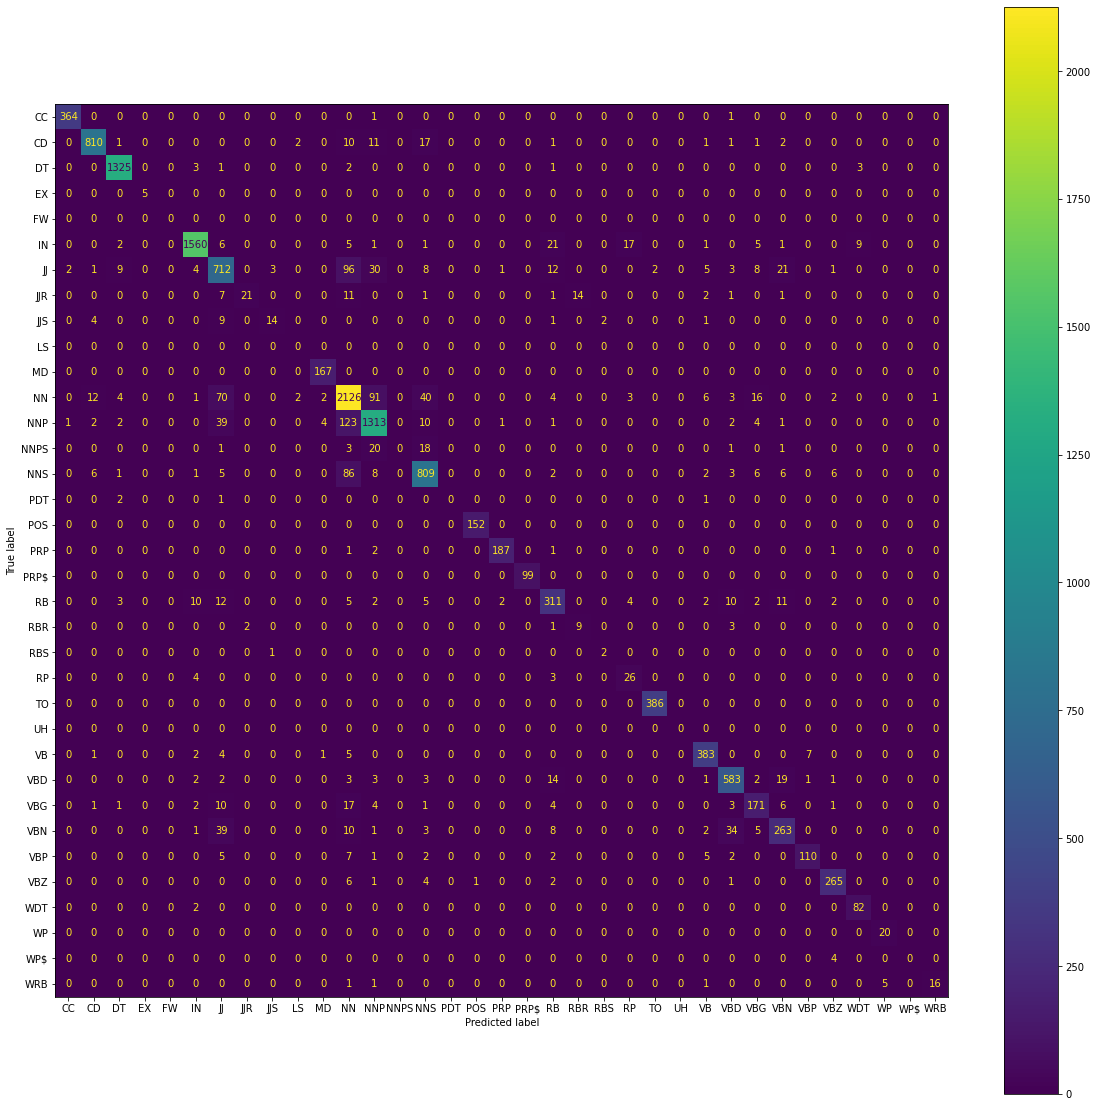

In [ ]:
disp = ConfusionMatrixDisplay(two_dense_conf_matrix, display_labels = true_labels)
fig, ax = plt.subplots(figsize=(20,20))
disp.plot(ax=ax)

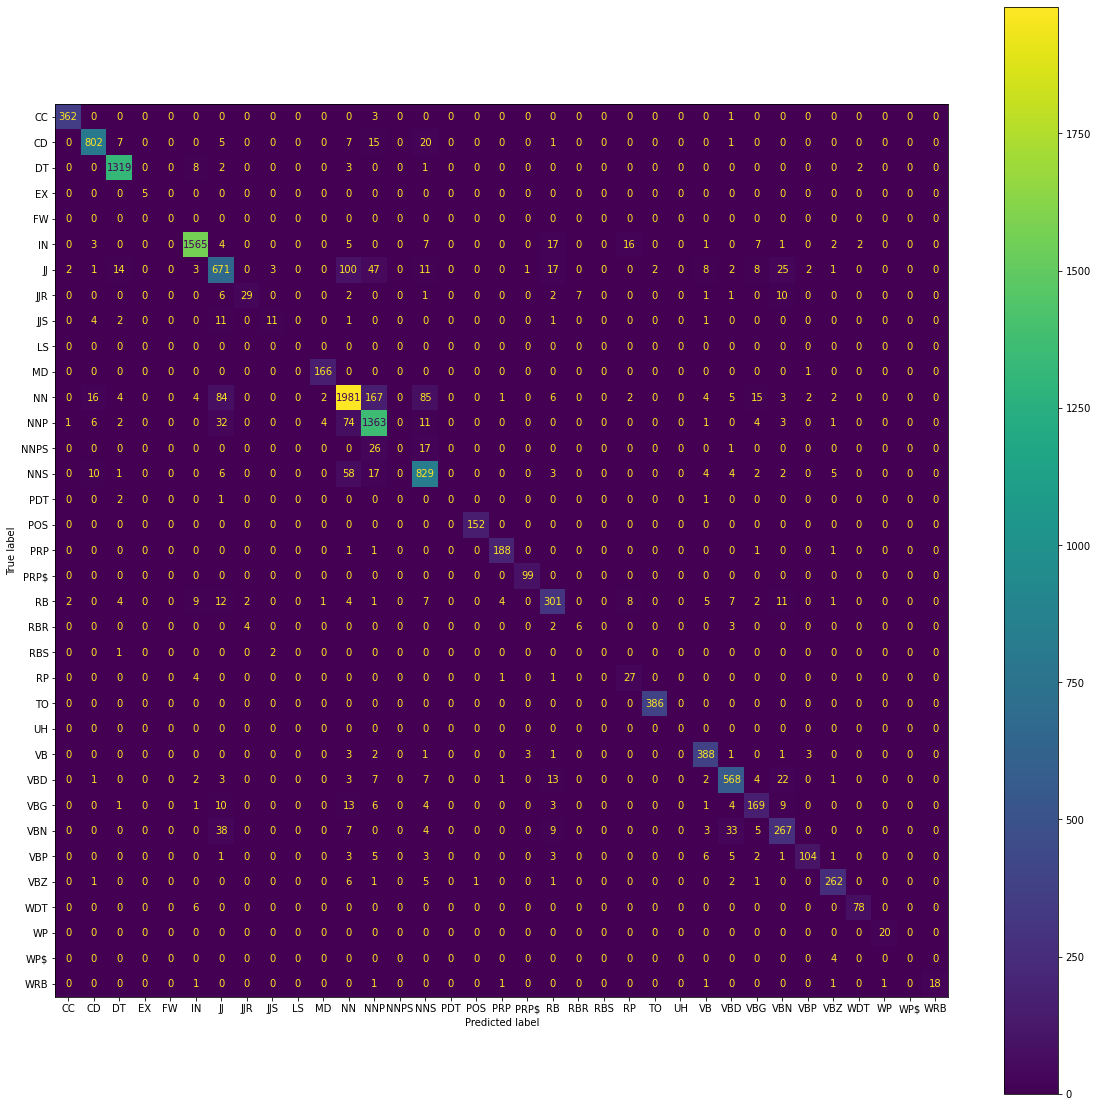

In [ ]:
disp = ConfusionMatrixDisplay(gru_conf_matrix, display_labels = true_labels)
fig, ax = plt.subplots(figsize=(20, 20))
disp.plot(ax=ax)

### Classification report
The classification report allows us to get into the details of each class, calculating precision, recall, and f1-score for each one. Both POS taggers perform well overall, with high precision and recall scores for most classes.

In both models, we can see that:

1. Labels with a support of zero also have a zero precision/recall/f1-score.
2. They are unable to classify some labels with very small support (such as WP$, PDT).

Both models have the lowest f1-score for the NNPS (plural proper noun) class. This label is either misclassified as NNS (plural noun) or NNP (singular proper noun). We certainly have a lack of training data for this class, and some words can also be ambiguous, as a general example:

1. "Oranges" can be a plural proper noun (e.g., "The Oranges are a family") or a common noun (e.g., "I bought some oranges at the store").
2. "Smiths" can be a plural proper noun (e.g., "The Smiths are coming over for dinner") or a singular proper noun (e.g., "I met Mr. Smith at the store").

The same reasoning can be applied to the RP (particle) label, which is sometimes misclassified as IN (Preposition or subordinating conjuction), for example:
in the sentence "[...] be taken over (RP)
by [...]", over is classified as a preposition. This
depends on the fact that "over" is commonly used
as a particle in phrasal verbs, and as a preposition
to talk about movement or position at a higher level
than something else.

In [ ]:
def get_classification_report(y_true, y_pred, true_labels):
    report = classification_report(y_true, y_pred, labels = true_labels, zero_division=0, output_dict= True)
    report = pd.DataFrame(report).transpose()
    report = report.iloc[~report.index.isin(['micro avg', 'macro avg', 'weighted avg'])].sort_values('support', axis=0, ascending=False)
    return report

In [ ]:
two_dense_report =  get_classification_report(flattened_y_true, flattened_td_y_pred, true_labels)
gru_report =  get_classification_report(flattened_y_true, flattened_gru_y_pred, true_labels)

In [ ]:
print(two_dense_report)

      precision    recall  f1-score  support
NN     0.844656  0.892153  0.867755   2383.0
IN     0.979899  0.957055  0.968343   1630.0
NNP    0.880617  0.873005  0.876795   1504.0
DT     0.981481  0.992509  0.986965   1335.0
NNS    0.877440  0.859724  0.868492    941.0
JJ     0.771398  0.775599  0.773493    918.0
CD     0.966587  0.944056  0.955189    858.0
VBD    0.895545  0.919558  0.907393    634.0
VB     0.927361  0.950372  0.938725    403.0
TO     0.994845  1.000000  0.997416    386.0
RB     0.797436  0.816273  0.806744    381.0
CC     0.991826  0.994536  0.993179    366.0
VBN    0.792169  0.718579  0.753582    366.0
VBZ    0.936396  0.946429  0.941385    280.0
VBG    0.777273  0.773756  0.775510    221.0
PRP    0.979058  0.973958  0.976501    192.0
MD     0.959770  1.000000  0.979472    167.0
POS    0.987013  1.000000  0.993464    152.0
VBP    0.932203  0.820896  0.873016    134.0
PRP$   1.000000  1.000000  1.000000     99.0
WDT    0.872340  0.976190  0.921348     84.0
JJR    0.9

In [ ]:
print(gru_report)

      precision    recall  f1-score  support
NN     0.871919  0.831305  0.851128   2383.0
IN     0.976294  0.960123  0.968141   1630.0
NNP    0.818619  0.906250  0.860208   1504.0
DT     0.971997  0.988015  0.979941   1335.0
NNS    0.818361  0.880978  0.848516    941.0
JJ     0.757336  0.730937  0.743902    918.0
CD     0.944641  0.934732  0.939660    858.0
VBD    0.890282  0.895899  0.893082    634.0
VB     0.908665  0.962779  0.934940    403.0
TO     0.994845  1.000000  0.997416    386.0
RB     0.790026  0.790026  0.790026    381.0
CC     0.986376  0.989071  0.987722    366.0
VBN    0.752113  0.729508  0.740638    366.0
VBZ    0.929078  0.935714  0.932384    280.0
VBG    0.768182  0.764706  0.766440    221.0
PRP    0.959184  0.979167  0.969072    192.0
MD     0.959538  0.994012  0.976471    167.0
POS    0.993464  1.000000  0.996721    152.0
VBP    0.928571  0.776119  0.845528    134.0
PRP$   0.961165  1.000000  0.980198     99.0
WDT    0.951220  0.928571  0.939759     84.0
JJR    0.8

### Performance Plot
Finally we plot a figure which compares the performance (f1-score) of the two models on the ten most frequent and least frequent classes.

This plot intuitively shows the better performance of the Two-Dense model.

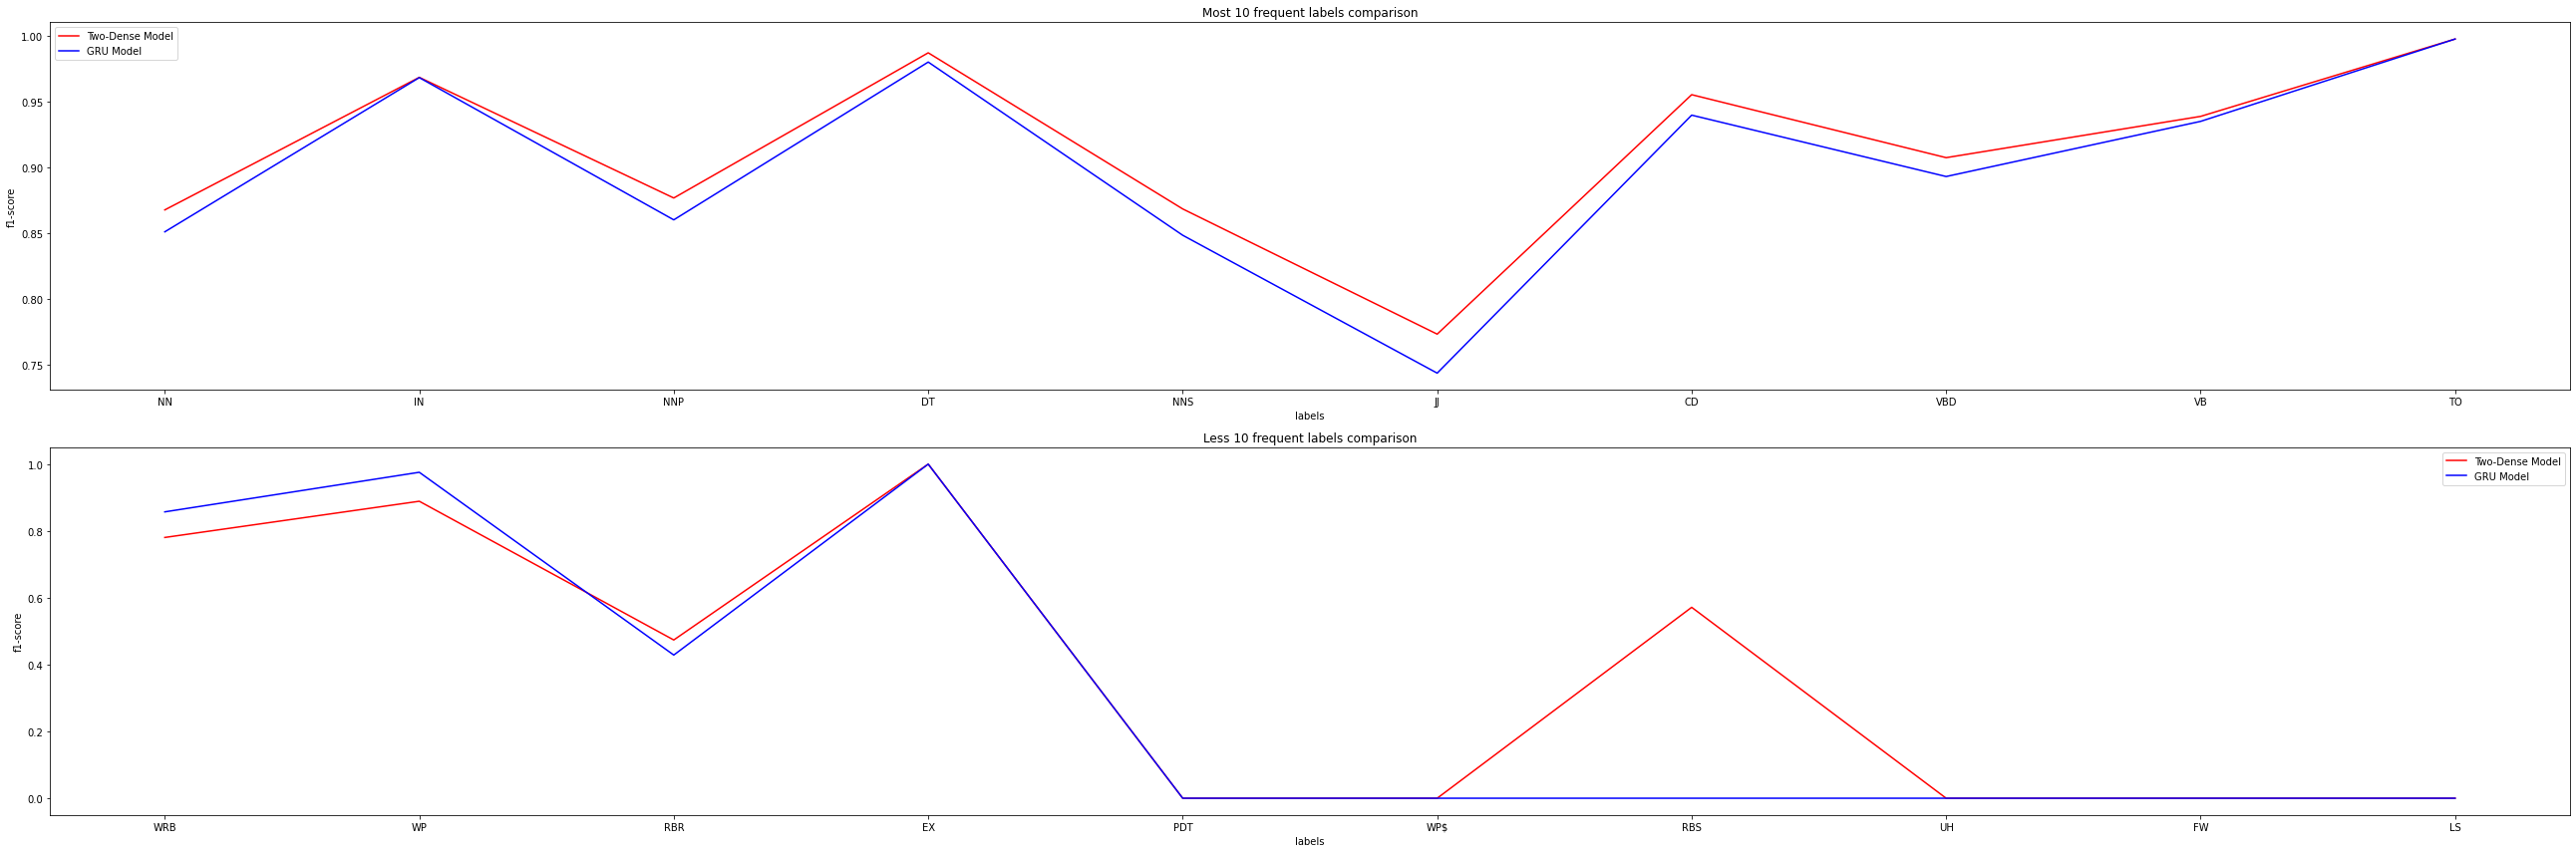

In [ ]:
labels_num = 10

fig, axs = plt.subplots(2)

top_classes_1 = two_dense_report[:labels_num]
top_classes_2 = gru_report[:labels_num]

less_classes_1 = two_dense_report[-labels_num:]
less_classes_2 = gru_report[-labels_num:]

line1, = axs[0].plot(top_classes_1.index, top_classes_1['f1-score'], color='red', label='Two-Dense Model')
line2, = axs[0].plot(top_classes_2.index, top_classes_2['f1-score'], color='blue', label='GRU Model')
axs[0].title.set_text(f'Most {labels_num} frequent labels comparison')


axs[1].plot(less_classes_1.index, less_classes_1['f1-score'], color='red', label='Two-Dense Model')
axs[1].plot(less_classes_2.index, less_classes_2['f1-score'], color='blue', label='GRU Model')
axs[1].title.set_text(f'Less {labels_num} frequent labels comparison')

#plt.plot(report.index, report['f1-score'], color='red')
axs[0].set_ylabel('f1-score')
axs[0].set_xlabel('labels')

axs[1].set_ylabel('f1-score')
axs[1].set_xlabel('labels')

axs[0].legend([line1, line2], ['Two-Dense Model', 'GRU Model'])
axs[1].legend([line1, line2], ['Two-Dense Model', 'GRU Model'])

fig.tight_layout()
plt.show()